# Compare Vabamorf with homonyms dataset


## Table of contents

1. [**Gathering Data**](#andmete_kogumine)
2. [**Inspecting Data**](#andmetesse_sissevaatamine)
3. [**Evaluation Vabamorf**](#hindamine_vabamorf)
4. [**Results Vabamorf**](#tulemused_vabamorf)
5. [**Evaluation BertMorphTaggerV1**](#hindamine_v1)
6. [**Results BertMorphTaggerV1**](#tulemused_v1)
7. [**Evaluation BertMorphTaggerV2**](#hindamine_V2)
8. [**Results BertMorphTaggerV2**](#tulemused_v2)
9. [**Evaluation BertMorphTaggerHomonymFull**](#hindamine_homonyms)
10. [**Results BertMorphTaggerHomonymFull**](#tulemused_homonyms)
11. [**Evaluation BertMorphTaggerHomonym_50**](#hindamine_homonyms_50)
12. [**Results BertMorphTaggerHomonym_50**](#tulemused_homonyms_50)
13. [**Results Baselines**](#tulemused_baseline)

[end](#end)


### Conclusive evaluation results for the models

> Note that the evaluation results are based on only the form label pairs, and thus do not take into account the POS tags.

| Model                      | Accuracy | Precision | Recall | F1-score |
| -------------------------- | -------: | --------: | -----: | -------: |
| Vabamorf                   |   83.30% |    82.93% | 83.30% |   83.01% |
| Bert_morph_v1              |   89.40% |    89.39% | 89.40% |   89.21% |
| Bert_morph_v2              |   94.61% |    95.48% | 94.61% |   95.01% |
| Bert_morph_v2_homonym_full |   99.87% |    99.90% | 99.87% |   99.89% |
| Bert_morph_v2_homonym_50   |   99.20% |    99.30% | 99.20% |   99.25% |

Since Bert_morph_v2_MoE_full gave the same results as Bert_morph_v2_homonym_full when evaluated on the homonyms dataset to predict both the form and POS labels, it is not included in the above results, so we can be sure that the MoE would give similar results as Bert_morph_v2_homonym_full on the homonyms dataset to predict only the form labels.


### Imports


In [1]:
print("Test")

Test


In [2]:
# Imports
import sys
import pathlib

# Add the project's root directory to the Python path
sys.path.append(pathlib.Path("../").resolve().as_posix())

# Configurations
seed = 42

# Paths
DATA_DIR = pathlib.Path("../data/")
ENC2017_ROOT = DATA_DIR / "enc2017"
UD_ET_EDT_ROOT = DATA_DIR / "ud_et_edt"
HOMONYMS_ROOT = DATA_DIR / "homonymous_word_forms"

ENC2017_DIRS = {
    "processed": ENC2017_ROOT / "processed",
    "raw": ENC2017_ROOT / "raw",
}

UD_ET_EDT_DIRS = {
    "processed": UD_ET_EDT_ROOT / "processed",
    "raw": UD_ET_EDT_ROOT / "raw",
}

HOMONYMS_DIRS = {
    "processed": HOMONYMS_ROOT / "processed",
    "annotations": HOMONYMS_ROOT / "annotations",
}

OUTPUT_DIR = pathlib.Path("../outputs/")

MODEL_DIR = pathlib.Path("../models/")

In [3]:
import os
import evaluate
import re
import pandas as pd
import numpy as np
import estnltk, estnltk.converters, estnltk.taggers
import sklearn
import sklearn.metrics

from typing import Any

import matplotlib.pyplot as plt
import seaborn as sns

# import importlib
# import scripts.model.bert_morph_tagger as bmt_module

# importlib.reload(bmt_module)
# BertMorphTagger = bmt_module.BertMorphTagger

# from bert_morph_tagger_notebook_functions import NotebookFunctions

# from simpletransformers.ner import NERModel, NERArgs
from tqdm import tqdm
from scripts.model.bert_morph_tagger import BertMorphTagger
from estnltk.converters.label_studio.labelling_configurations import (
    PhraseClassificationConfiguration,
)
from estnltk.converters.label_studio.labelling_tasks import PhraseClassificationTask

e:\Git_projects\EstNLTK\simpletransformers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
poseval = evaluate.load("evaluate-metric/poseval", module_type="metric")


def custom_metrics(preds, labels):

    # Evaluate using poseval
    result = poseval.compute(predictions=preds, references=labels, zero_division=0)

    return result

In [5]:
# Additional helper functions included before the main APIs:
def _validate_columns(
    results_df: pd.DataFrame,
    pred_col: str,
    true_col: str,
    group_col: str | None = None,
) -> None:
    """Validate that required columns exist in the results dataframe.

    Parameters
    ----------
    results_df : pd.DataFrame
        Dataframe containing evaluation results.
    pred_col : str
        Column name for predicted labels.
    true_col : str
        Column name for true labels.
    group_col : str | None, optional
        Optional column name used for grouped reporting/plotting.

    Raises
    ------
    ValueError
        If one or more required columns are missing.
    """
    required_columns: set[str] = {pred_col, true_col}
    if group_col is not None:
        required_columns.add(group_col)

    missing_columns = [col for col in required_columns if col not in results_df.columns]
    if missing_columns:
        raise ValueError(
            f"Missing required columns in results dataframe: {missing_columns}"
        )


def _build_group_save_path(save_path: str, group_value: Any) -> str:
    """Build a group-specific save path by appending a safe suffix.

    Parameters
    ----------
    save_path : str
        Base save path from the user.
    group_value : Any
        Group value used in the filename suffix.

    Returns
    -------
    str
        Save path with a group-specific suffix.
    """
    path = pathlib.Path(save_path)
    safe_group = re.sub(r"[^\w\-.]+", "_", str(group_value))
    return str(path.with_name(f"{path.stem}_{safe_group}{path.suffix}"))


def _normalise_true_label(label_value: Any) -> str:
    """Normalise true-label value to a single string label.

    Parameters
    ----------
    label_value : Any
        Raw label value from dataframe row.

    Returns
    -------
    str
        Cleaned label string.
    """
    if label_value is None or pd.isna(label_value):
        return "missing_true_label"

    if isinstance(label_value, list):
        if not label_value:
            return "missing_true_label"
        return str(label_value[0])

    label_text = str(label_value)
    if label_text.startswith("['") and label_text.endswith("']"):
        return label_text[2:-2]
    if label_text.startswith('["') and label_text.endswith('"]'):
        return label_text[2:-2]

    return label_text


def _extract_prediction_from_layer(
    text: estnltk.Text, layer_name: str, target_span: str
) -> str | None:
    """Extract first form prediction from an EstNLTK layer for target span.

    Parameters
    ----------
    text : estnltk.Text
        Text object with tagged layers.
    layer_name : str
        Layer name to inspect (e.g., "bert_morph_tagging", "morph_analysis").
    target_span : str
        Span string in format '(start, end)'.

    Returns
    -------
    str | None
        Predicted form label or None if no matching annotation is found.
    """
    layer = getattr(text, layer_name, None)
    if layer is None:
        return None

    for annotation in layer:
        annotation_span = str((annotation.start, annotation.end))
        if annotation_span == target_span:
            prediction = annotation.form[0]
            if isinstance(prediction, list):
                prediction = prediction[0] if prediction else None
            return prediction

    return None


def annotate_sentences_with_model(
    input_df: pd.DataFrame,
    model_name: str,
    output_csv_path: str | None = None,
    progress_desc: str = "Evaluating model vs Vabamorf",
    sentence_col: str = "sentence",
    word_col: str = "word",
    word_span_col: str = "word_span",
    true_label_col: str = "label",
    num_col: str = "num",
    inflection_type_col: str = "inflection_type",
    model_prediction_col: str = "pred_label",
) -> pd.DataFrame:
    """Annotate sentences with selected model and Vabamorf baseline.

    Parameters
    ----------
    input_df : pd.DataFrame
        Input dataframe containing sentence-level data to evaluate.
    model_name : str
        Model path for BertMorphTagger or string "Vabamorf".
    output_csv_path : str | None, optional
        If provided, save results dataframe to this CSV path.
    progress_desc : str, optional
        Description shown in tqdm progress bar.
    sentence_col : str, optional
        Column name containing sentence text.
    word_col : str, optional
        Column name containing analysed word text.
    word_span_col : str, optional
        Column name containing analysed word span.
    true_label_col : str, optional
        Column name containing true label.
    num_col : str, optional
        Column name containing source/group id.
    inflection_type_col : str, optional
        Column name containing inflection type.
    model_prediction_col : str, optional
        Name of output column for selected model predictions.

    Returns
    -------
    pd.DataFrame
        Evaluation results dataframe with prediction columns.
    """
    required_columns = [sentence_col, word_col, word_span_col, true_label_col]
    optional_columns = [num_col, inflection_type_col]
    missing_columns = [
        column_name
        for column_name in required_columns
        if column_name not in input_df.columns
    ]
    if missing_columns:
        raise ValueError(f"Missing required input columns: {missing_columns}")

    from estnltk.default_resolver import make_resolver

    resolver = make_resolver()
    use_vabamorf_as_model = model_name.strip().lower() == "vabamorf"
    bmt_model = None
    if not use_vabamorf_as_model:
        bmt_model = BertMorphTagger(model_location=str(model_name))

    results: list[dict[str, Any]] = []
    outer = tqdm(
        input_df.iterrows(),
        total=len(input_df),
        desc=progress_desc,
    )

    for _, row in outer:
        sentence_text = row[sentence_col]
        target_span = str(row[word_span_col])

        text = estnltk.Text(sentence_text)
        text.tag_layer("sentences")

        if use_vabamorf_as_model:
            text.tag_layer(resolver=resolver)
            model_prediction = _extract_prediction_from_layer(
                text=text,
                layer_name="morph_analysis",
                target_span=target_span,
            )
        else:
            bmt_model.tag(text)
            model_prediction = _extract_prediction_from_layer(
                text=text,
                layer_name="bert_morph_tagging",
                target_span=target_span,
            )

        result_row: dict[str, Any] = {
            "sentence": sentence_text,
            "word": row[word_col],
            "true_label": _normalise_true_label(row[true_label_col]),
            model_prediction_col: model_prediction,
        }

        for optional_column in optional_columns:
            if optional_column in input_df.columns:
                result_row[optional_column] = row[optional_column]

        results.append(result_row)
        outer.refresh()

    results_df = pd.DataFrame(results)

    if output_csv_path is not None:
        output_path = pathlib.Path(output_csv_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        results_df.to_csv(output_path, index=False)

    return results_df


def _print_metrics(y_true: pd.Series, y_pred: pd.Series, title: str) -> None:
    """Compute and print weighted metrics for a prediction task.

    Parameters
    ----------
    y_true : pd.Series
        True labels.
    y_pred : pd.Series
        Predicted labels.
    title : str
        Header title for the printed block.
    """
    accuracy = sklearn.metrics.accuracy_score(y_true=y_true, y_pred=y_pred)
    precision, recall, f1_score, _ = sklearn.metrics.precision_recall_fscore_support(
        y_true=y_true,
        y_pred=y_pred,
        average="weighted",
        zero_division=0,
    )

    print(title)
    print(f"Accuracy:  {accuracy:.2%}")
    print(f"Precision: {precision:.2%}")
    print(f"Recall:    {recall:.2%}")
    print(f"F1-score:  {f1_score:.2%}")


def display_metrics_and_classification_report(
    results_df: pd.DataFrame,
    pred_col: str,
    true_col: str,
    group_col: str | None = None,
    show_metrics: bool = True,
    show_classification_report: bool = True,
) -> None:
    """Display evaluation metrics and/or classification reports.

    Parameters
    ----------
    results_df : pd.DataFrame
        Dataframe containing evaluation results.
    pred_col : str
        Column name from which predicted labels are read.
    true_col : str
        Column name from which true labels are read.
    group_col : str | None, optional
        Optional grouping column for per-group results.
    show_metrics : bool, optional
        If True, print weighted metrics (accuracy, precision, recall, F1).
    show_classification_report : bool, optional
        If True, print sklearn classification report.
    """
    _validate_columns(results_df, pred_col, true_col, group_col)

    if not show_metrics and not show_classification_report:
        print(
            "Nothing to display: both show_metrics and show_classification_report are False."
        )
        return

    # Work on a copy and normalise missing values to avoid sklearn errors.
    data = results_df.copy()
    data[pred_col] = data[pred_col].fillna("-")
    data[true_col] = data[true_col].fillna("-")

    def _display_block(block_df: pd.DataFrame, title: str) -> None:
        y_true = block_df[true_col]
        y_pred = block_df[pred_col]

        if show_metrics:
            _print_metrics(y_true=y_true, y_pred=y_pred, title=title)

        if show_classification_report:
            print(f"{title} - Classification Report")
            print(
                sklearn.metrics.classification_report(
                    y_true=y_true,
                    y_pred=y_pred,
                    zero_division=0,
                )
            )

    if group_col is None:
        _display_block(data, "Overall results")
        return

    for group_value in sorted(data[group_col].dropna().unique()):
        group_data = data[data[group_col] == group_value]
        _display_block(group_data, f"{group_col}={group_value}")


def plot_confusion_matrices(
    results_df: pd.DataFrame,
    pred_col: str,
    true_col: str,
    group_col: str | None = None,
    save_path: str | None = None,
    significant_pred_threshold_pct: float = 1.0,
    show_excluded_predictions: bool = True,
) -> None:
    """Plot normalised confusion matrix/matrices with filtered rows.

    Rows always contain only labels present in true labels.
    Predicted-only labels are shown as additional columns only when their
    prediction share is >= `significant_pred_threshold_pct`.
    """
    if significant_pred_threshold_pct < 0:
        raise ValueError("significant_pred_threshold_pct must be >= 0")

    _validate_columns(results_df, pred_col, true_col, group_col)

    data = results_df.copy()
    data[pred_col] = data[pred_col].fillna("-")
    data[true_col] = data[true_col].fillna("-")

    def _show_predicted_only_summary(
        block_df: pd.DataFrame,
        pred_only_labels: list[str],
        significant_pred_only_labels: list[str],
        title: str,
    ) -> None:
        if not show_excluded_predictions or not pred_only_labels:
            return

        pred_counts = block_df[pred_col].value_counts(dropna=False)
        total_count = max(len(block_df), 1)
        summary_df = pd.DataFrame(
            {
                "predicted_only_label": pred_only_labels,
                "count": [int(pred_counts.get(label, 0)) for label in pred_only_labels],
            }
        )
        summary_df["share_pct"] = (summary_df["count"] / total_count * 100).round(2)
        summary_df["included_in_plot"] = summary_df["predicted_only_label"].isin(
            significant_pred_only_labels
        )
        summary_df["threshold_pct"] = significant_pred_threshold_pct
        summary_df = summary_df.sort_values(
            by="share_pct", ascending=False
        ).reset_index(drop=True)

        print(f"{title} - Predicted-only labels (not present in true labels):")
        try:
            print(summary_df)
            print(f"Sum of true labels count: {total_count}")
        except NameError:
            print(summary_df.to_string(index=False))

    def _plot_one(
        block_df: pd.DataFrame, title: str, one_save_path: str | None
    ) -> None:
        y_true = block_df[true_col].astype(str)
        y_pred = block_df[pred_col].astype(str)

        true_labels = sorted(y_true.unique().tolist())
        predicted_labels = sorted(y_pred.unique().tolist())
        pred_only_labels = [
            label for label in predicted_labels if label not in set(true_labels)
        ]

        pred_distribution_pct = y_pred.value_counts(normalize=True).mul(100)
        significant_pred_only_labels = [
            label
            for label in pred_only_labels
            if float(pred_distribution_pct.get(label, 0.0))
            >= significant_pred_threshold_pct
        ]

        plot_pred_labels = true_labels + [
            label for label in significant_pred_only_labels if label not in true_labels
        ]

        cm_counts = pd.crosstab(y_true, y_pred).reindex(
            index=true_labels,
            columns=plot_pred_labels,
            fill_value=0,
        )
        cm = cm_counts.to_numpy(dtype=float)

        row_sums = cm.sum(axis=1, keepdims=True)
        with np.errstate(divide="ignore", invalid="ignore"):
            cm_normalised = np.divide(cm, row_sums, where=row_sums != 0)
        cm_normalised = np.nan_to_num(cm_normalised, nan=0.0)

        plt.figure(figsize=(8, 8))
        sns.heatmap(
            cm_normalised,
            annot=True,
            fmt=".2%",
            cmap="Blues",
            xticklabels=plot_pred_labels,
            yticklabels=true_labels,
        )
        plt.title(
            f"{title} (extra predicted-only columns >= {significant_pred_threshold_pct:.2f}%)"
        )
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.tight_layout()

        if one_save_path is not None:
            output_path = pathlib.Path(one_save_path)
            output_path.parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(output_path, dpi=300)

        plt.show()

        _show_predicted_only_summary(
            block_df=block_df,
            pred_only_labels=pred_only_labels,
            significant_pred_only_labels=significant_pred_only_labels,
            title=title,
        )

    if group_col is None:
        _plot_one(
            block_df=data,
            title=f"{pred_col} vs {true_col}",
            one_save_path=save_path,
        )
        return

    for group_value in sorted(data[group_col].dropna().unique()):
        group_data = data[data[group_col] == group_value]
        group_save_path = None
        if save_path is not None:
            group_save_path = _build_group_save_path(
                save_path=save_path, group_value=group_value
            )

        _plot_one(
            block_df=group_data,
            title=f"Confusion Matrix ({group_col}={group_value}): {pred_col} vs {true_col}",
            one_save_path=group_save_path,
        )

<a id='andmete_kogumine'></a>


### Gathering data


In [123]:
# Use specific annotation configurations that were used in homonyms dataset
annotation_confs = {
    1: PhraseClassificationConfiguration(
        phrase_labels=["analüüsitav sõna"],
        class_labels={"sg n": "sg n", "sg g": "sg g"},
        header="Vali sõna morfoloogiline vorm (sg n - ainsuse nimetav, sg g -- ainsuse omastav):",
        header_placement="middle",
    ),
    16: PhraseClassificationConfiguration(
        phrase_labels=["analüüsitav sõna"],
        class_labels={"sg n": "sg n", "sg g": "sg g"},
        header="Vali sõna morfoloogiline vorm (sg n - ainsuse nimetav, sg g -- ainsuse omastav):",
        header_placement="middle",
    ),
    17: PhraseClassificationConfiguration(
        phrase_labels=["analüüsitav sõna"],
        class_labels={"sg n": "sg n", "sg g": "sg g", "sg p": "sg p"},
        header="Vali sõna morfoloogiline vorm (sg n - ainsuse nimetav, sg g - ainsuse omastav, sg p - ainsuse osastav):",
        header_placement="middle",
    ),
    19: PhraseClassificationConfiguration(
        phrase_labels=["analüüsitav sõna"],
        class_labels={"sg g": "sg g", "sg p": "sg p", "adt": "adt"},
        header="Vali sõna morfoloogiline vorm (sg g - ainsuse omastav, sg p - ainsuse osastav, adt - lühike sisseütlev):",
        header_placement="middle",
    ),
}

In [124]:
# Collect input files
input_files = []
input_dir = "../data/homonymous_word_forms/annotations/"
for fname in os.listdir(input_dir):
    if os.path.isdir(os.path.join(input_dir, fname)):
        for subfname in os.listdir(os.path.join(input_dir, fname)):
            if subfname.endswith(".json"):
                inflection_type = int(subfname.split("_")[2])  # infl_type_xx_1000_vx...
                input_files.append(
                    (
                        inflection_type,
                        "../data/homonymous_word_forms/annotations/"
                        + fname
                        + "/"
                        + subfname,
                    )
                )

if not input_files:
    raise RuntimeError("No input files found!")

print(f"Found {len(input_files)} input files.")

Found 8 input files.


In [151]:
overall_data = []
# Extract data from input files
for infl_type, input_file in input_files:
    print(f"Processing file: {input_file} (inflection type {infl_type})")
    num = int(pathlib.Path(input_file).parent.stem)
    annotation_conf = annotation_confs[infl_type]
    with open(input_file, "r", encoding="utf-8") as f:
        raw = f.read()
    task = PhraseClassificationTask(
        annotation_conf,
        input_layer="morph",
        output_layer="morph",
        label_attribute="label",
    )
    classified_sentences = task.import_data(raw)

    # Create dataframe from classified sentences
    data = []
    for sentence_id, sentence in enumerate(classified_sentences):
        for annotation in sentence.morph:
            if (
                "class_label" in sentence.meta
                and sentence.meta["class_label"] is not None
            ):
                data.append(
                    {
                        "num": num,
                        "inflection_type": infl_type,
                        "sentence": sentence.text,
                        "word": annotation.text,
                        "word_span": (annotation.start, annotation.end),
                        "label": sentence.meta["class_label"],
                        "sentence_id": sentence_id,
                        "source": pathlib.Path(input_file).name,
                    }
                )
    # df = pd.DataFrame(data)
    # output_csv = HOMONYMS_DIRS["processed"] / pathlib.Path(f"homonyms_annotated_infltype_{num}_{infl_type}.csv")
    # df.to_csv(output_csv, index=False)
    # print(f"Saved processed data to {output_csv}")
    overall_data.extend(data)

# Create overall dataframe
overall_df = pd.DataFrame(overall_data)
overall_output_csv = HOMONYMS_DIRS["processed"] / pathlib.Path(
    "homonyms_annotated_overall.csv"
)
overall_df.to_csv(overall_output_csv, index=False)
print(f"Saved overall processed data to {overall_output_csv}")

Processing file: ../data/homonymous_word_forms/annotations/1/infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json (inflection type 1)
Processing file: ../data/homonymous_word_forms/annotations/1/infl_type_16_1000_v1_project-2-at-2024-11-21-19-27-9e8ae0c2.json (inflection type 16)
Processing file: ../data/homonymous_word_forms/annotations/1/infl_type_17_1000_v1.json (inflection type 17)
Processing file: ../data/homonymous_word_forms/annotations/1/infl_type_19_1000_v1_project-6-at-2025-11-15-14-13-42753676.json (inflection type 19)
Processing file: ../data/homonymous_word_forms/annotations/2/infl_type_01_1000_v2_project-5-at-2024-12-11-21-53-280753b4.json (inflection type 1)
Processing file: ../data/homonymous_word_forms/annotations/2/infl_type_16_1000_v2_project-5-at-2025-01-03-01-42-87bca577.json (inflection type 16)
Processing file: ../data/homonymous_word_forms/annotations/2/infl_type_17_1000_v2.json (inflection type 17)
Processing file: ../data/homonymous_word_forms/anno

<a id='andmetesse_sissevaatamine'></a>


### Inspecting Data


In [6]:
overall_df = pd.read_csv(
    "../data/homonymous_word_forms/processed/homonyms_annotated_overall.csv"
)

In [7]:
overall_df.groupby(["inflection_type", "label"]).size().reset_index().sort_values(
    by="inflection_type"
)

,inflection_type,label,0
0,1,['sg g'],1232
1,1,['sg n'],764
2,16,['sg g'],1080
3,16,['sg n'],890
4,17,['sg g'],524
5,17,['sg n'],791
6,17,['sg p'],609
7,19,['adt'],94
8,19,['sg g'],1621
9,19,['sg p'],281


In [8]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,sentence_id,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"(74, 80)",['sg n'],0,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"(20, 27)",['sg n'],1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"(51, 60)",['sg n'],2,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"(16, 20)",['sg n'],3,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"(0, 7)",['sg g'],4,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


<a id='hindamine_vabamorf'></a>


### Evaluation Vabamorf


In [62]:
model_name = "Vabamorf"

In [ ]:
results_df = annotate_sentences_with_model(
    input_df=overall_df,
    model_name=model_name,
    output_csv_path=str(
        HOMONYMS_DIRS["processed"] / "homonyms_annotations_vabamorf.csv"
    ),
    progress_desc="Evaluating Vabamorf on homonyms dataset",
)

Evaluating Vabamorf on homonyms dataset: 100%|██████████| 7886/7886 [01:03<00:00, 123.60it/s]


In [64]:
display(results_df.head())

,sentence,word,true_label,pred_label,num,inflection_type
0,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,sg n,sg n,1,1
1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,sg n,sg n,1,1
2,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,sg n,sg n,1,1
3,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,sg n,sg n,1,1
4,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,sg g,sg g,1,1


<a id='tulemused_vabamorf'></a>


### Results Vabamorf


In [11]:
results_df = pd.read_csv(
    HOMONYMS_DIRS["processed"] / "homonyms_annotations_vabamorf.csv",
    index_col=False,
)

In [12]:
print("Vabamorf results:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)

Vabamorf results:
Overall results
Accuracy:  83.30%
Precision: 82.93%
Recall:    83.30%
F1-score:  83.01%


In [13]:
print("Vabamorf classification report:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=False,
    show_classification_report=True,
)

Vabamorf classification report:
Overall results - Classification Report
              precision    recall  f1-score   support

         adt       0.47      0.29      0.36        94
           o       0.00      0.00      0.00         0
        pl p       0.00      0.00      0.00         0
       sg es       0.00      0.00      0.00         0
        sg g       0.86      0.90      0.88      4457
        sg n       0.83      0.80      0.82      2445
        sg p       0.72      0.63      0.67       890

    accuracy                           0.83      7886
   macro avg       0.41      0.37      0.39      7886
weighted avg       0.83      0.83      0.83      7886



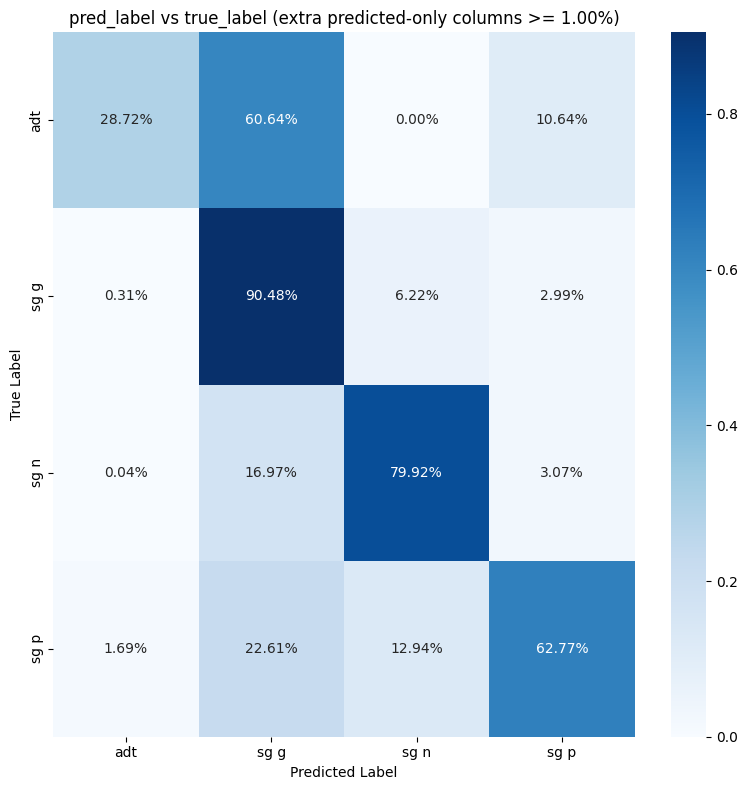

pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                sg es      2       0.03             False            1.0
1                    o      1       0.01             False            1.0
2                 pl p      1       0.01             False            1.0
Sum of true labels count: 7886


In [14]:
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    save_path=str(OUTPUT_DIR / "plots" / "homonyms" / "Vabamorf" / "VabamorfCM.png"),
)

In [ ]:
# Analyse results where Vabamorf predicted "sg g", but the true label was "adt"
sg_g_as_adt = results_df[
    (results_df["pred_label"] == "sg g") & (results_df["true_label"] == "adt")
]
print(sg_g_as_adt["inflection_type"].value_counts())
print(sg_g_as_adt["word"].value_counts().head(5))
display(sg_g_as_adt)

inflection_type
19    57
Name: count, dtype: int64
word
muuseumi       7
komisjoni      7
Washingtoni    6
gümnaasiumi    4
restorani      4
Name: count, dtype: int64
94


,sentence,word,true_label,pred_label,num,inflection_type
2993,"Jaapani ärimees Masahito Otsuka kulutas oma unelmale, maailma tuntuimate kunstiteoste reprodutseerimisele ja nende ebatavalisse uude muuseumi koondamisele, 400 miljonit dollarit.",muuseumi,adt,sg g,1,19
3002,"""Ühe Euroopa sõidu ajal, kui arvati, et see idarahvas on natuke rumal, ja taheti presidendile tõlki, ütles Meri mikrofoni inglise keeles, et tal on vaja küsimusi, mitte tõlki!"" lausub 7. klassi poiss Tõnis.",mikrofoni,adt,sg g,1,19
3013,"Samas on kõik uue kodu lähistel asuvad koolid sellised, mis võtavad gümnaasiumi vastu katsetega.",gümnaasiumi,adt,sg g,1,19
3061,"""Kas mu poiss saab ikka sisse gümnaasiumi, kuhu soovis?",gümnaasiumi,adt,sg g,1,19
3078,Need inimesed astuvad palju tõenäolisemalt sisse ka näiteks muuseumi.,muuseumi,adt,sg g,1,19
3085,"Kõigil uutel telefonidel on värviline ekraan, paljudel on Java tugi ehk võimalus telefoni ise programme ja mänge lisada.",telefoni,adt,sg g,1,19
3087,"Võite pommitamise lõpetada,"" kirjutas ta Belgradi tagasi saadetud teates.",Belgradi,adt,sg g,1,19
3141,Vabatahtlikult Viru pataljoni aega teenima läinud Aleksei Levin (22) on ainuke sel aastal kaitseväkke kutsutud kõrgharidusega ajateenija.,pataljoni,adt,sg g,1,19
3177,"Tshetsheenia 20. sajandil 1922 november - Tshetsheenia autonoomse oblasti loomine 1924 - Ingushshia autonoomse oblasti loomine 1934 - kahe oblasti liitumine 1937 - Stalini ""puhastuse"" käigus vahistati kaks protsenti tshetsheenidest 1940-44 - ülestõusud Hassan Israilovi juhtimisel 1944 - tshetsheenide kollektiivne deporteerimine Kasahstani seoses väidetava kollaboratsiooniga 1953 - Stalini surma järel naasesid tshetsheenid kodudesse 1956 - otsus taastada rahvuslikud territooriumid 1957 - maad saadi vähem kui enne 1944. aastat 1992 oktoober - Tshetsheenia parlamendivalimised, Dzhohhar Dudajev sai presidendiks 2. november - Tshetsheenia iseseisvuse väljakuulutamine 1993 märts - nurjus esimene Dudajevi-vastane putsh 1994 - kolm nurjunud putshi 1994 detsember - Vene väed marssisid Tshetsheeniasse, sõja algus 1996 aprill - Dudajev sai surma, tema mantlipärijaks sai Zelimhan Jandarbijev 1996 mai - Jeltsin ja Jandarbijev sõlmivad Kremlis vaherahu 1996 august - Jeltsini julgeolekunõunik Aleksandr Lebed ja Tshetsheenia kindralstaabi ülem Aslan Mashadov sõlmisid rahulepingu, mis jätab Tshetsheenia staatuse viieks aastaks lahtiseks 1996 september - Vene väed lahkusid 1996 jaanuar - Mashadov valiti presidendiks 1999 august - Tshetsheeni islamistid sõjapealike Shamil Bassajevi ja Hattabi juhtimisel tungisid Dagestani, püüdes seal kehtestada islamirezhiimi.",Dagestani,adt,sg g,1,19
3198,"Hanson läheb tuikudes oma ministeeriumi, näeb trepikojas kantsler Kannikut, kes palitut hoolsasti riidepuu peale seab, ja hüüab, ise õnnest purjus : ""Ah, armas kantsler, mida teie volbriööl teete?""",ministeeriumi,adt,sg g,1,19


In [33]:
from estnltk.default_resolver import make_resolver

resolver = make_resolver()

ma = (
    estnltk.Text(
        "Küll aga ootasime ära valitsuse seisukoha, mis jõudis meie komisjoni eelmisel nädalal."
    )
    .tag_layer(resolver=resolver)
    .morph_analysis
)
html = getattr(ma, "_repr_html_", None)
if html:
    content = html()
    with open("morph_analysis.html", "w", encoding="utf-8") as f:
        f.write(content)
display(ma)

Layer(name='morph_analysis', attributes=('normalized_text', 'lemma', 'root', 'root_tokens', 'ending', 'clitic', 'form', 'partofspeech'), spans=SL[Span('Küll', [{'normalized_text': 'Küll', 'lemma': 'küll', 'root': 'küll', 'root_tokens': ['küll'], 'ending': '0', 'clitic': '', 'form': '', 'partofspeech': 'D'}]),
Span('aga', [{'normalized_text': 'aga', 'lemma': 'aga', 'root': 'aga', 'root_tokens': ['aga'], 'ending': '0', 'clitic': '', 'form': '', 'partofspeech': 'J'}]),
Span('ootasime', [{'normalized_text': 'ootasime', 'lemma': 'ootama', 'root': 'oota', 'root_tokens': ['oota'], 'ending': 'sime', 'clitic': '', 'form': 'sime', 'partofspeech': 'V'}]),
Span('ära', [{'normalized_text': 'ära', 'lemma': 'ära', 'root': 'ära', 'root_tokens': ['ära'], 'ending': '0', 'clitic': '', 'form': '', 'partofspeech': 'D'}]),
Span('valitsuse', [{'normalized_text': 'valitsuse', 'lemma': 'valitsus', 'root': 'valitsus', 'root_tokens': ['valitsus'], 'ending': '0', 'clitic': '', 'form': 'sg g', 'partofspeech': 'S'}]),
Span('seisukoha', [{'normalized_text': 'seisukoha', 'lemma': 'seisukoht', 'root': 'seisu_koht', 'root_tokens': ['seisu', 'koht'], 'ending': '0', 'clitic': '', 'form': 'sg g', 'partofspeech': 'S'}]),
Span(',', [{'normalized_text': ',', 'lemma': ',', 'root': ',', 'root_tokens': [','], 'ending': '', 'clitic': '', 'form': '', 'partofspeech': 'Z'}]),
Span('mis', [{'normalized_text': 'mis', 'lemma': 'mis', 'root': 'mis', 'root_tokens': ['mis'], 'ending': '0', 'clitic': '', 'form': 'sg n', 'partofspeech': 'P'}, {'normalized_text': 'mis', 'lemma': 'mis', 'root': 'mis', 'root_tokens': ['mis'], 'ending': '0', 'clitic': '', 'form': 'pl n', 'partofspeech': 'P'}]),
Span('jõudis', [{'normalized_text': 'jõudis', 'lemma': 'jõudma', 'root': 'jõud', 'root_tokens': ['jõud'], 'ending': 'is', 'clitic': '', 'form': 's', 'partofspeech': 'V'}]),
Span('meie', [{'normalized_text': 'meie', 'lemma': 'mina', 'root': 'mina', 'root_tokens': ['mina'], 'ending': '0', 'clitic': '', 'form': 'pl g', 'partofspeech': 'P'}]),
Span('komisjoni', [{'normalized_text': 'komisjoni', 'lemma': 'komisjon', 'root': 'komisjon', 'root_tokens': ['komisjon'], 'ending': '0', 'clitic': '', 'form': 'sg g', 'partofspeech': 'S'}]),
Span('eelmisel', [{'normalized_text': 'eelmisel', 'lemma': 'eelmine', 'root': 'eelmine', 'root_tokens': ['eelmine'], 'ending': 'l', 'clitic': '', 'form': 'sg ad', 'partofspeech': 'A'}]),
Span('nädalal', [{'normalized_text': 'nädalal', 'lemma': 'nädal', 'root': 'nädal', 'root_tokens': ['nädal'], 'ending': 'l', 'clitic': '', 'form': 'sg ad', 'partofspeech': 'S'}]),
Span('.', [{'normalized_text': '.', 'lemma': '.', 'root': '.', 'root_tokens': ['.'], 'ending': '', 'clitic': '', 'form': '', 'partofspeech': 'Z'}])])

In [91]:
print("Vabamorf results per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=True,
    show_classification_report=False,
)

Vabamorf results per inflection type:
inflection_type=1
Accuracy:  87.07%
Precision: 87.04%
Recall:    87.07%
F1-score:  87.05%
inflection_type=16
Accuracy:  87.66%
Precision: 88.17%
Recall:    87.66%
F1-score:  87.85%
inflection_type=17
Accuracy:  72.97%
Precision: 73.89%
Recall:    72.97%
F1-score:  73.01%
inflection_type=19
Accuracy:  85.17%
Precision: 84.23%
Recall:    85.17%
F1-score:  84.55%


In [92]:
print("Vabamorf classification reports per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=False,
    show_classification_report=True,
)

Vabamorf classification reports per inflection type:
inflection_type=1 - Classification Report
              precision    recall  f1-score   support

        sg g       0.89      0.90      0.90      1232
        sg n       0.84      0.82      0.83       764

    accuracy                           0.87      1996
   macro avg       0.86      0.86      0.86      1996
weighted avg       0.87      0.87      0.87      1996

inflection_type=16 - Classification Report
              precision    recall  f1-score   support

         adt       0.00      0.00      0.00         0
           o       0.00      0.00      0.00         0
       sg es       0.00      0.00      0.00         0
        sg g       0.87      0.91      0.89      1080
        sg n       0.89      0.83      0.86       890
        sg p       0.00      0.00      0.00         0

    accuracy                           0.88      1970
   macro avg       0.29      0.29      0.29      1970
weighted avg       0.88      0.88      0.88    

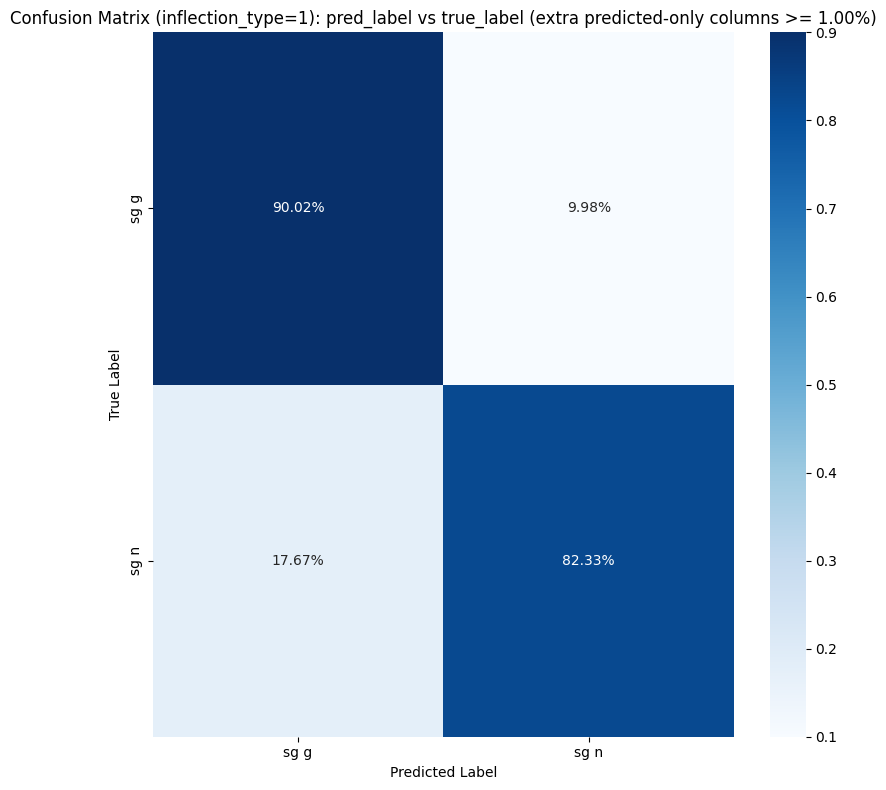

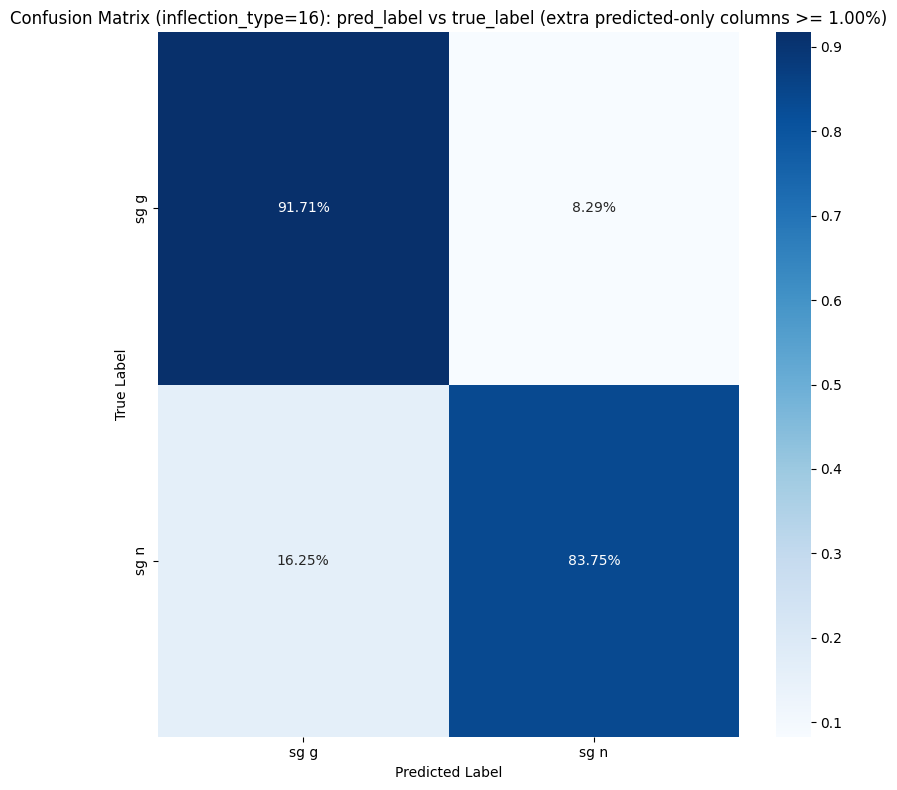

Confusion Matrix (inflection_type=16): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg p      6       0.30             False            1.0
1                sg es      2       0.10             False            1.0
2                    o      1       0.05             False            1.0
3                  adt      1       0.05             False            1.0
Sum of true labels count: 1970


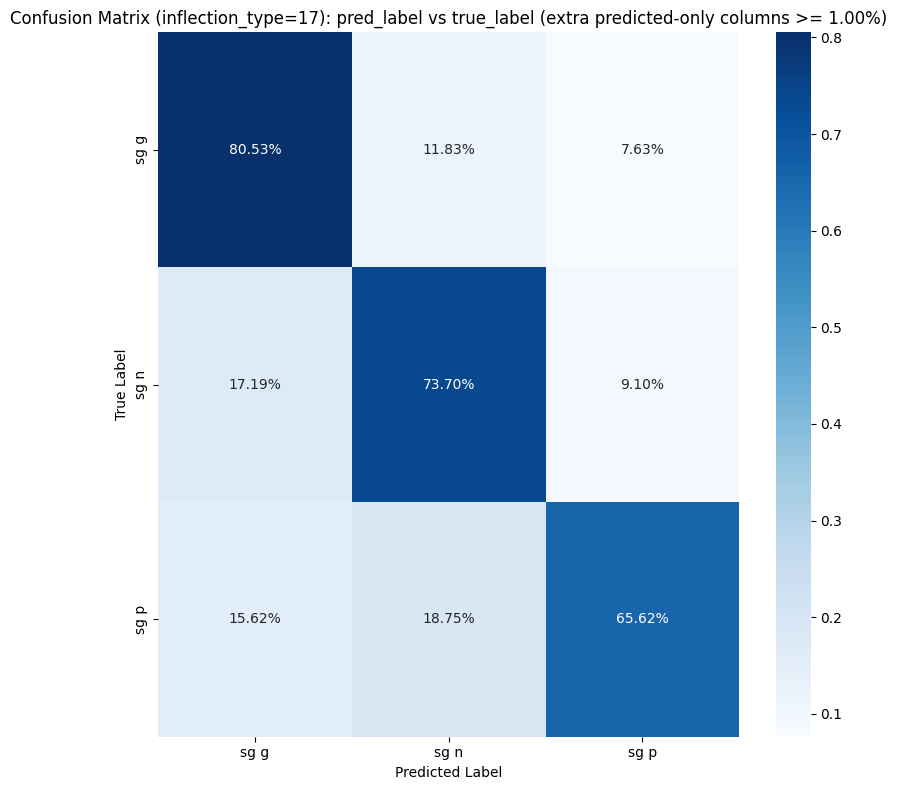

Confusion Matrix (inflection_type=17): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 pl p      1       0.05             False            1.0
Sum of true labels count: 1924


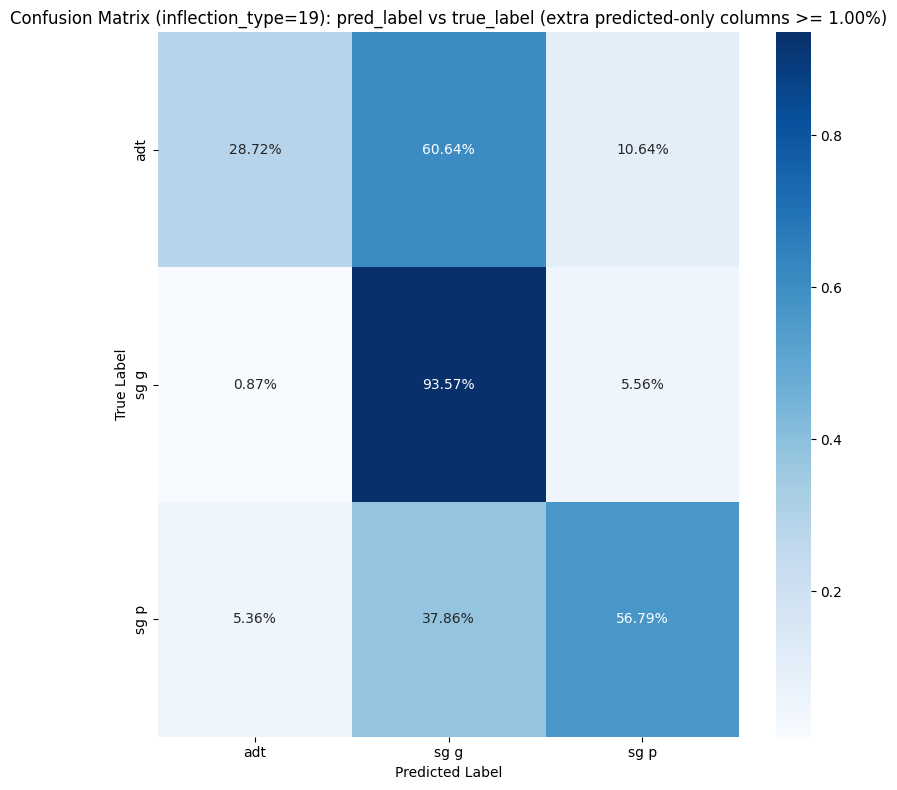

Confusion Matrix (inflection_type=19): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg n      4        0.2             False            1.0
Sum of true labels count: 1996


In [93]:
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    save_path=str(
        OUTPUT_DIR / "plots" / "homonyms" / "Vabamorf" / "VabamorfCM_infl.png"
    ),
)

<a id='hindamine_v1'></a>


### Evaluation BertMorphTaggerV1


In [6]:
# Define model to use for annotation
model_name = "../models/NER_mudel/"

In [9]:
results_df = annotate_sentences_with_model(
    input_df=overall_df,
    model_name=model_name,
    output_csv_path=str(
        HOMONYMS_DIRS["processed"] / "homonyms_annotations_Bert_morph_V1.csv"
    ),
    progress_desc="Evaluating BertMorphTaggerV1 on homonyms dataset",
)

Evaluating BertMorphTaggerV1 on homonyms dataset: 100%|██████████| 7886/7886 [06:36<00:00, 19.90it/s]


In [10]:
display(results_df.head())

,sentence,word,true_label,pred_label,num,inflection_type
0,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,sg n,sg n,1,1
1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,sg n,sg n,1,1
2,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,sg n,sg n,1,1
3,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,sg n,sg n,1,1
4,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,sg g,sg g,1,1


<a id='tulemused_v1'></a>


### Results BertMorphTaggerV1


In [94]:
# Load results dataframe
results_df = pd.read_csv(
    HOMONYMS_DIRS["processed"] / "homonyms_annotations_Bert_morph_V1.csv",
    index_col=False,
)

print("BertMorphTaggerV1 results:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)

BertMorphTaggerV1 results:
Overall results
Accuracy:  89.40%
Precision: 89.39%
Recall:    89.40%
F1-score:  89.21%


In [95]:
# Print classification reports
print("BertMorphTaggerV1 classification report:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV1 classification report:
Overall results - Classification Report
              precision    recall  f1-score   support

           -       0.00      0.00      0.00         0
           ?       0.00      0.00      0.00         0
         adt       0.72      0.35      0.47        94
          da       0.00      0.00      0.00         0
          me       0.00      0.00      0.00         0
           o       0.00      0.00      0.00         0
        pl g       0.00      0.00      0.00         0
        pl p       0.00      0.00      0.00         0
       sg ad       0.00      0.00      0.00         0
        sg g       0.91      0.95      0.93      4457
      sg ill       0.00      0.00      0.00         0
        sg n       0.90      0.88      0.89      2445
        sg p       0.84      0.70      0.77       890

    accuracy                           0.89      7886
   macro avg       0.26      0.22      0.23      7886
weighted avg       0.89      0.89      0.89      7886

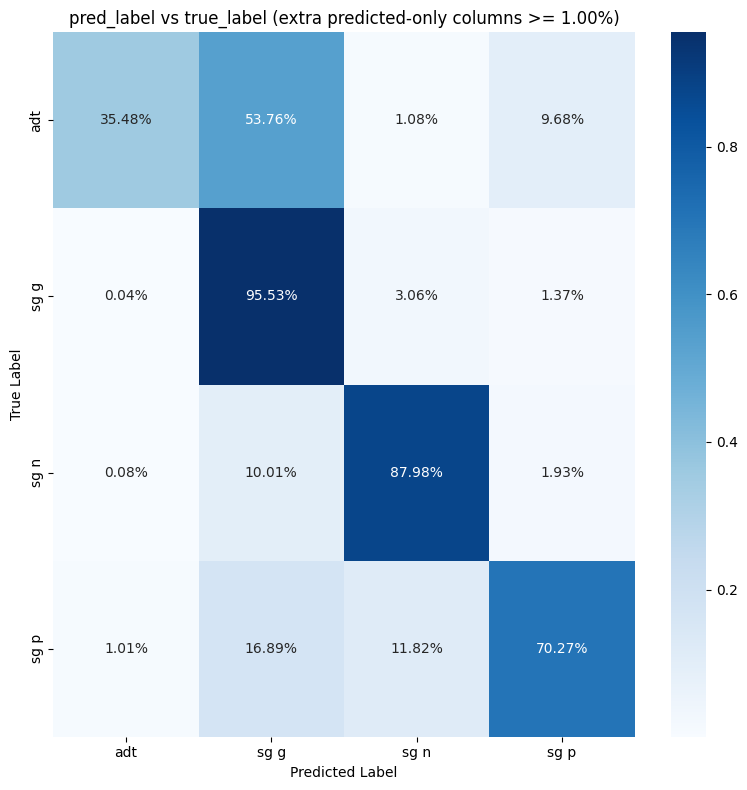

pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    -     10       0.13             False            1.0
1                 pl g      3       0.04             False            1.0
2                    ?      1       0.01             False            1.0
3                   me      1       0.01             False            1.0
4                   da      1       0.01             False            1.0
5                    o      1       0.01             False            1.0
6                 pl p      1       0.01             False            1.0
7                sg ad      1       0.01             False            1.0
8               sg ill      1       0.01             False            1.0
Sum of true labels count: 7886


In [96]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    save_path=str(
        OUTPUT_DIR / "plots" / "homonyms" / "Bert_morph_v1" / "BertMorphTaggerCM.png"
    ),
)

In [97]:
# Generate results per inflection type
print("BertMorphTaggerV1 results per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=True,
    show_classification_report=False,
)

BertMorphTaggerV1 results per inflection type:
inflection_type=1
Accuracy:  93.49%
Precision: 93.82%
Recall:    93.49%
F1-score:  93.65%
inflection_type=16
Accuracy:  92.84%
Precision: 93.33%
Recall:    92.84%
F1-score:  93.07%
inflection_type=17
Accuracy:  80.56%
Precision: 81.53%
Recall:    80.56%
F1-score:  80.66%
inflection_type=19
Accuracy:  90.43%
Precision: 90.23%
Recall:    90.43%
F1-score:  89.71%


In [98]:
# Generate classification reports per inflection type
print("BertMorphTaggerV1 classification reports per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV1 classification reports per inflection type:
inflection_type=1 - Classification Report
              precision    recall  f1-score   support

           ?       0.00      0.00      0.00         0
         adt       0.00      0.00      0.00         0
          da       0.00      0.00      0.00         0
        pl g       0.00      0.00      0.00         0
        sg g       0.95      0.95      0.95      1232
        sg n       0.92      0.92      0.92       764

    accuracy                           0.93      1996
   macro avg       0.31      0.31      0.31      1996
weighted avg       0.94      0.93      0.94      1996

inflection_type=16 - Classification Report
              precision    recall  f1-score   support

           -       0.00      0.00      0.00         0
          me       0.00      0.00      0.00         0
           o       0.00      0.00      0.00         0
        sg g       0.93      0.95      0.94      1080
        sg n       0.94      0.91      

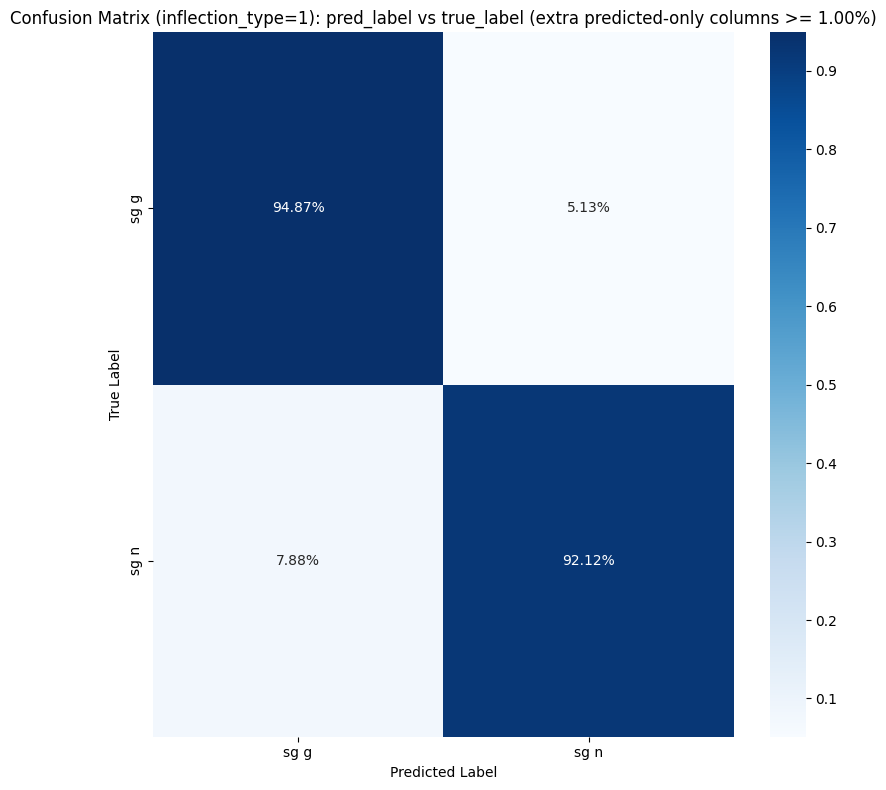

Confusion Matrix (inflection_type=1): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 pl g      3       0.15             False            1.0
1                  adt      2       0.10             False            1.0
2                    ?      1       0.05             False            1.0
3                   da      1       0.05             False            1.0
Sum of true labels count: 1996


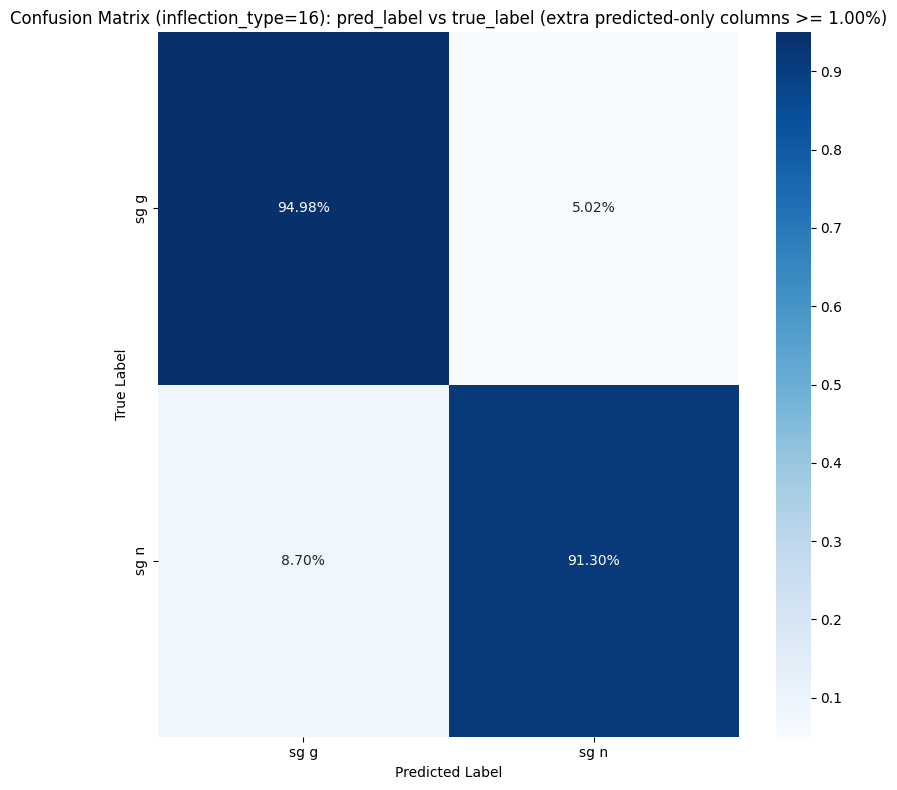

Confusion Matrix (inflection_type=16): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    -      4       0.20             False            1.0
1                 sg p      4       0.20             False            1.0
2                   me      1       0.05             False            1.0
3                    o      1       0.05             False            1.0
Sum of true labels count: 1970


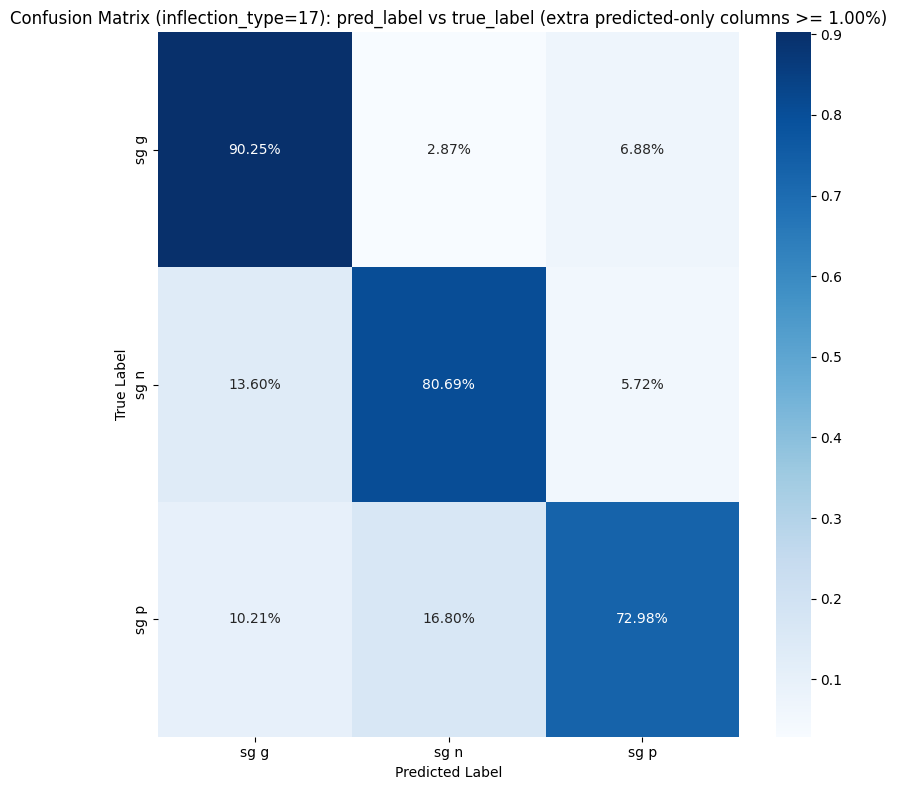

Confusion Matrix (inflection_type=17): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    -      6       0.31             False            1.0
1                 pl p      1       0.05             False            1.0
Sum of true labels count: 1924


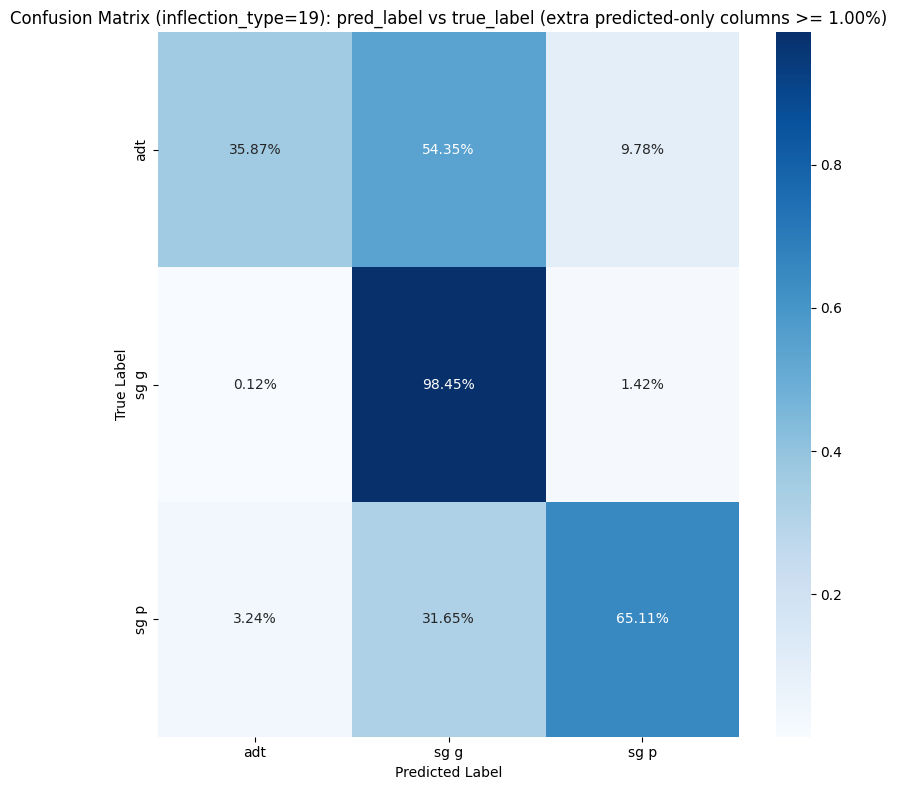

Confusion Matrix (inflection_type=19): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg n      8       0.40             False            1.0
1                sg ad      1       0.05             False            1.0
2               sg ill      1       0.05             False            1.0
Sum of true labels count: 1996


In [99]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    save_path=str(
        OUTPUT_DIR
        / "plots"
        / "homonyms"
        / "Bert_morph_v1"
        / "BertMorphTaggerCM_infl.png"
    ),
)

<a id='hindamine_v2'></a>


### Evaluation BertMorphTaggerV2


In [71]:
# Define model to use for annotation
model_name = "../models/NER_mudel_v2/"

In [72]:
results_df = annotate_sentences_with_model(
    input_df=overall_df,
    model_name=model_name,
    output_csv_path=str(
        HOMONYMS_DIRS["processed"] / "homonyms_annotations_Bert_morph_V2.csv"
    ),
    progress_desc="Evaluating BertMorphTaggerV2 on homonyms dataset",
)

Evaluating BertMorphTaggerV2 on homonyms dataset: 100%|██████████| 7886/7886 [06:54<00:00, 19.01it/s]


In [73]:
display(results_df.head())

,sentence,word,true_label,pred_label,num,inflection_type
0,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,sg n,sg n,1,1
1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,sg n,sg n,1,1
2,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,sg n,sg n,1,1
3,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,sg n,sg n,1,1
4,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,sg g,sg g,1,1


<a id='tulemused_v2'></a>


### Results BertMorphTaggerV2


In [100]:
# Load results dataframe
results_df = pd.read_csv(
    HOMONYMS_DIRS["processed"] / "homonyms_annotations_Bert_morph_V2.csv",
    index_col=False,
)

print("BertMorphTaggerV2 results:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)

BertMorphTaggerV2 results:
Overall results
Accuracy:  94.66%
Precision: 95.48%
Recall:    94.66%
F1-score:  95.03%


In [101]:
# Print classification reports
print("BertMorphTaggerV2 classification report:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV2 classification report:
Overall results - Classification Report
              precision    recall  f1-score   support

           -       0.00      0.00      0.00         0
         adt       0.96      0.74      0.84        94
          me       0.00      0.00      0.00         0
           o       0.00      0.00      0.00         0
        pl g       0.00      0.00      0.00         0
        pl p       0.00      0.00      0.00         0
        sg g       0.96      0.98      0.97      4457
        sg n       0.96      0.91      0.94      2445
        sg p       0.90      0.90      0.90       890

    accuracy                           0.95      7886
   macro avg       0.42      0.39      0.41      7886
weighted avg       0.95      0.95      0.95      7886



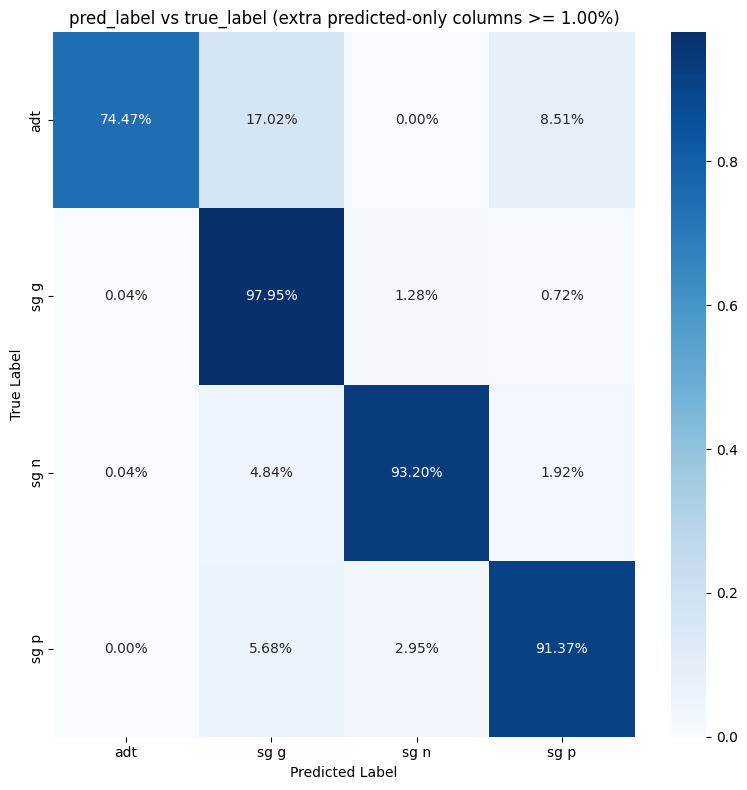

pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    -     63       0.80             False            1.0
1                   me      1       0.01             False            1.0
2                    o      1       0.01             False            1.0
3                 pl g      1       0.01             False            1.0
4                 pl p      1       0.01             False            1.0
Sum of true labels count: 7886


In [102]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    save_path=str(
        OUTPUT_DIR / "plots" / "homonyms" / "Bert_morph_v2" / "BertMorphTaggerCM.png"
    ),
)

In [103]:
# Analyse results where BertMorphTagger predicted "sg g", but the true label was "adt"
sg_g_as_adt = results_df[
    (results_df["pred_label"] == "sg g") & (results_df["true_label"] == "adt")
]
print(sg_g_as_adt["inflection_type"].value_counts())
print(sg_g_as_adt["word"].value_counts().head(5))
display(sg_g_as_adt)
# Analyse results where BertMorphTagger predicted "sg p", but the true label was "adt"
sg_p_as_adt = results_df[
    (results_df["pred_label"] == "sg p") & (results_df["true_label"] == "adt")
]
print(sg_p_as_adt["inflection_type"].value_counts())
print(sg_p_as_adt["word"].value_counts().head(5))
display(sg_p_as_adt)

inflection_type
19    16
Name: count, dtype: int64
word
mikrofoni      2
gümnaasiumi    2
restorani      2
muuseumi       2
Washingtoni    1
Name: count, dtype: int64


,sentence,word,true_label,pred_label,num,inflection_type
3002,"""Ühe Euroopa sõidu ajal, kui arvati, et see idarahvas on natuke rumal, ja taheti presidendile tõlki, ütles Meri mikrofoni inglise keeles, et tal on vaja küsimusi, mitte tõlki!"" lausub 7. klassi poiss Tõnis.",mikrofoni,adt,sg g,1,19
3013,"Samas on kõik uue kodu lähistel asuvad koolid sellised, mis võtavad gümnaasiumi vastu katsetega.",gümnaasiumi,adt,sg g,1,19
3248,Kolkjasse Kala-Sibula restorani jõudmiseks kulub tallinlasel umbes kolm ja pool tundi.,restorani,adt,sg g,1,19
3497,Hiljem tuleb tunnussõnaga numbri valimiseks vajutada aparaadi küljel olevale nupule ning öelda aparaadi või hands-free mikrofoni tunnussõna ning telefon valibki soovitava numbri.,mikrofoni,adt,sg g,1,19
3527,Ajalehe Ha'aretz teatel sõidab Peres Cairosse neljapäeval enne järgmise nädala visiiti Washingtoni kõnelustele USA välisministri Colin Powelliga.,Washingtoni,adt,sg g,1,19
3532,"Moskva teatas kavatusest 540 km pikkune piir sulgeda läinud nädalal, reageerides sellega tshetsheeni islamivõitlejate tungimisele üle piiri Dagestani ja pommiplahvatustele Venemaal.",Dagestani,adt,sg g,1,19
3550,"Tagantjärelegi on tal raske mõista, miks võtsid professoritest vangid leedulane Kezgailo ja lätlane Ošins endale suure riski : kui neil tekkis võimalus võtta haigla personali lisaks üks meditsiinitöötaja, valisid nad Laane.",personali,adt,sg g,1,19
3572,"Warner Bros lükkas oktoobrist veebruari uue Arnold Schwarzeneggeri filmi ""Kaasnevad purustused"" (Collateral damage) esilinastuse, sest seal on juttu õhkulastud pilvelõhkujast.",veebruari,adt,sg g,1,19
3763,"Raha, sõjatehnika ja instruktorid lähevad Indoneesiasse, Usbekistani, Nepali, Jordaaniasse, Pakistani, Kasahstani, Kõrgõzstani ja Usbekistani, kinnitas kaitseministeeriumi esindaja.",Usbekistani,adt,sg g,1,19
3823,"Pärast viimast sõda asus ta tööle Tallinna, alul loodusteaduste muuseumi, hiljem töötas Õpetajate Täiendusinstituudis ja Tallinna Pedagoogilises Instituudis.",muuseumi,adt,sg g,1,19


inflection_type
19    8
Name: count, dtype: int64
word
restorani    2
alkoholi     2
telefoni     1
terminali    1
tribunali    1
Name: count, dtype: int64


,sentence,word,true_label,pred_label,num,inflection_type
2981,"Pealinna tänavail ringi uidates tungisid neist kolm restorani, kus lükkasid ümber laudu ja toole ning mugisid porgandeid.",restorani,adt,sg p,1,19
3113,"Ameerika ülikoolid püüavad kaitsta verisulis elluastujaid alkoholi uppumast, Eesti kõrgkoolid seni mitte",alkoholi,adt,sg p,1,19
3921,"""Eesti alkoholi suhtutakse üldiselt üleolevalt,"" räägib Tschakkar, ""tavaliselt võetakse pidudele ükskõik mis jooki, peaasi, et välismaine.",alkoholi,adt,sg p,1,19
7088,"Või läheks hiina restorani sööma, härra Allikmaa?",restorani,adt,sg p,2,19
7456,Väga ilusasti ütles see daam telefoni.,telefoni,adt,sg p,2,19
7664,Foto : Rauno Volmar Estonian Air hakkab alates 25. märtsist lendama Pariisi Charles de Gaulle'i lennujaama terminali 1 senise terminali 2B asemel.,terminali,adt,sg p,2,19
7808,"Lõoke olevat öelnud, et ""kõik kommunistid tuleb hävitada"", seda pandi talle süüks ning kõik kätte saadud rakkelastest omakaitselased toodi tribunali tunnistama.",tribunali,adt,sg p,2,19
7874,"""Pidage rangelt kinni raportiteks ette nähtud kellaaegadest!"" kõmistas ta mikrofoni, ise samal ajal ""külalistetoas"" temperatuuri tõstes.",mikrofoni,adt,sg p,2,19


BertMorphTaggerV2 pakub lühikese sisseütleva (`adt`) asemel omastava (`sg g`), osastava (`sg p`) või nimetava (`sg n`) käände vormi. Kõik näited on muuttüübist 19.


In [104]:
# Analyse results where BertMorphTagger predicted "sg n", but the true label was "sg g"
sg_n_as_sg_g = results_df[
    (results_df["pred_label"] == "sg n") & (results_df["true_label"] == "sg g")
]
print(sg_n_as_sg_g["inflection_type"].value_counts())
print(sg_n_as_sg_g["word"].value_counts().head(5))
display(sg_n_as_sg_g)
# Analyse results where BertMorphTagger predicted "sg p", but the true label was "sg g"
sg_p_as_sg_g = results_df[
    (results_df["pred_label"] == "sg p") & (results_df["true_label"] == "sg g")
]
print(sg_p_as_sg_g["inflection_type"].value_counts())
print(sg_p_as_sg_g["word"].value_counts().head(5))
display(sg_p_as_sg_g)

inflection_type
16    28
1     26
17     2
19     1
Name: count, dtype: int64
word
Saku          5
korraldaja    2
aasta         2
juhataja      1
võitja        1
Name: count, dtype: int64


,sentence,word,true_label,pred_label,num,inflection_type
38,Andres Ülviste Paetisme - Pühapäeval läheb Eesti suveajale.,Ülviste,sg g,sg n,1,1
103,56 spordiajakirjanikku 36 riigist valisid aasta spordiisiksuseks tänavuse Tour de France'i võitja Lance Armstrongi (USA).,võitja,sg g,sg n,1,1
178,Võrumaa veterinaarkeskuse juhataja Neeme Truija arvates jääb neid tõenäoliselt alles kaks.,juhataja,sg g,sg n,1,1
384,Halinga Puu raamatupidamises ei kajastu ka H & N Finantseerimisgrupi 264 386 dollari suurune nõue.,Halinga,sg g,sg n,1,1
498,"Eks Kaubamaja kaubamärgiga opereerirva AS-i Veneetsia Kaupmees omaniku Eesti Talleksi juhataja Ivar Simson ütles, et Eks Kaubamaja kavatseb likviiduskriisist üle saada kaubavarude mahamüümisega.",Veneetsia,sg g,sg n,1,1
516,"Tallinna, Tartu, Pärnu ja mõned muud on juba käes.",Tartu,sg g,sg n,1,1
642,Ürituse korraldaja Merle Ljubimova sõnul võivad mõned jalutuskäiketenduse stseenid libahuntide ja kummitustega publikut ehmatadagi.,korraldaja,sg g,sg n,1,1
834,EPMÜ avalikkussuhete korraldaja Katrin Uindi sõnul suurt tseremooniat ei korraldata.,korraldaja,sg g,sg n,1,1
869,Jäähokiliigas NHL alistas Ottawa Senators 4 : 1 Colorado Avalanche.,Ottawa,sg g,sg n,1,1
1024,"Heati esitosinasse avamängus Atlanta Hawksi vastu valiti tagamängijad Tim Hardaway, Sasha Danilovic, Dan Majerle, Voshon Lenard, Gary Grant, ründajad Kurt Thomas, Keith Askins, Mark Strickland, Ed Pinckney, keskmängijad Alonzo Mourning, P.J Brown ja Isaac Austin.",Atlanta,sg g,sg n,1,16


inflection_type
17    22
19     7
16     3
Name: count, dtype: int64
word
elu      4
raha     4
kahju    3
vaba     2
osa      2
Name: count, dtype: int64


,sentence,word,true_label,pred_label,num,inflection_type
1317,"Aastatel 1999-2002 vargustega kokku 4,2 miljonit krooni kahju tekitanud jõugu käekiri oli robustne.",kahju,sg g,sg p,1,16
1799,Ringkonnakohtu 12. novembri otsuse järgi peab Tartu linnavalitsus kannatanuks osutunud naisterahvale hüvitama talvises avariis sõiduautole Jaguar tekkinud kahju.,kahju,sg g,sg p,1,16
2064,"Teine neiu soovib kaitseväelase elu läbi teha selleks, et hiljem asuda õppima Riigikaitse Akadeemiasse, rääkis Seppik.",elu,sg g,sg p,1,17
2206,Õhtul külastasid kirikupead Haapsalu püha Maarja – Magdaleena kirikut.,püha,sg g,sg p,1,17
2389,"Marks & Spencer näiteks ehitas oma maine Suurbritannias suures osas sellele, et klient võis ostetud kauba poodi tuua ja selle eest raha tagasi saada, ilma, et peaks vingus näoga müüjalt seda teenet välja lunima.",raha,sg g,sg p,1,17
2514,""" Ta mõtleb ühe minuti kestnud kolme kilomeetri pikkust vaba langemist.",vaba,sg g,sg p,1,17
2559,See maksis aga nelja inimese elu.,elu,sg g,sg p,1,17
2583,"Juhtimiskeskus nagu kaptenisild Kuid ka pime kana leiab tera, ütleb kõnekäänd.",tera,sg g,sg p,1,17
2602,"Seejärel anti luba kõigil laiali minna, kes tahtis, võis võtta tööst vaba päeva.",vaba,sg g,sg p,1,17
2760,"Arstid kardavad, et tema ainus neer võis häda saada.",häda,sg g,sg p,1,17


BertMorphTaggerV2 pakub omastava (`sg g`) asemel nimetava (`sg n`) käände vormi. Rohkem on vigu muuttüüpidel 16 ja 1.

Samuti pakub BertMorphTaggerV2 omastava (`sg g`) asemel osastava (`sg p`) käände vormi. Rohkem on vigu muuttüübil 17.


In [105]:
# Analyse results where BertMorphTagger predicted "sg g", but the true label was "sg n"
sg_g_as_sg_n = results_df[
    (results_df["pred_label"] == "sg g") & (results_df["true_label"] == "sg n")
]
print(sg_g_as_sg_n["inflection_type"].value_counts())
print(sg_g_as_sg_n["word"].value_counts().head(5))
display(sg_g_as_sg_n)

inflection_type
17    65
1     29
16    22
Name: count, dtype: int64
word
Eesti       11
sama         9
elu          5
juhataja     5
maja         4
Name: count, dtype: int64


,sentence,word,true_label,pred_label,num,inflection_type
180,Kõnealused valikukriteeriumid lisatakse artikli 5 lõike 1 punktis b osutatud lepingule ja on kõnealuse lepingu lahutamatu osa.,lahutamatu,sg n,sg g,1,1
199,"Kauplustes 18 krooni maksva Shamtu šampooni (Fruity Power) reklaam oleks otsekui mõne imala armastusfilmi paroodia seltskond tüdrukuid käpib tualettruumis oma juukseid, misjärel minnakse rokikontserdile, kus võrgutatakse ära solist, kes Shamtu šampooniga pead pesnud neiu lavale kutsub ja talle naeratab...",paroodia,sg n,sg g,1,1
449,Lootusrikkalt alanud spordikarjäärile tõmbas kriipsu raske küünarliigese vigastus.,raske,sg n,sg g,1,1
466,"Kui ma olin ühe sellise ära joonud, siis mõtlesin, et aasta aega ei taha enam.",aasta,sg n,sg g,1,1
518,"Püsivad rohusöötade saagid, proteiinirikka silo tehnoloogia ja mobiilse laudatehnika kättesaadavus ning põlvkondade pikkune kogemus võimaldavad edukalt majandada piimakarja.",tehnoloogia,sg n,sg g,1,1
...,...,...,...,...,...,...
6778,"Aasta algusest on Ühispanga Elukindlustus kogunud 69, 3 miljonit krooni kindlustuspreemiaid, võrrelduna 2001. aasta sama perioodiga on preemiate maht kasvanud 51 protsenti.",sama,sg n,sg g,2,17
6784,Sama seaduse § 6 kohaselt kinnitab arengukava koostamise ülesande ja tähtaja valitsus.,Sama,sg n,sg g,2,17
6792,Mittelenduvate ainete määramine propioonhappes (E 280) II lisa 3. meetodi abil.,lisa,sg n,sg g,2,17
6801,"Eestis elavad vene kodanikud on täielikku patiseisu sattunud - ühelt poolt protestitakse väidetavalt liiga rangete kodakondsusnõuete üle, teiselt poolt aga mõistetakse (kui mõistetakse), et Eesti kodakondsuseta ei saa nad ka Euroopa Liidu kodanikeks ega saa osa liidu kodanike privileegidest, näiteks vaba liikumise võimalusest.",vaba,sg n,sg g,2,17


BertMorphTaggerV2 pakub nimetava (`sg n`) asemel omastava (`sg g`) käände vormi. Näited on muuttüüpidest 17, 1, 16. Sagedasemad vead on sõnadega "Eesti", "sama", "elu", "juhataja" ja "maja".


In [106]:
# Analyse results where BertMorphTagger predicted "sg g", but the true label was "sg p"
sg_g_as_sg_p = results_df[
    (results_df["pred_label"] == "sg g") & (results_df["true_label"] == "sg p")
]
print(sg_g_as_sg_p["inflection_type"].value_counts())
print(sg_g_as_sg_p["word"].value_counts().head(5))
display(sg_g_as_sg_p)
# Analyse results where BertMorphTagger predicted "sg n", but the true label was "sg p"
sg_n_as_sg_p = results_df[
    (results_df["pred_label"] == "sg n") & (results_df["true_label"] == "sg p")
]
print(sg_n_as_sg_p["inflection_type"].value_counts())
print(sg_n_as_sg_p["word"].value_counts().head(5))
display(sg_n_as_sg_p)

inflection_type
17    35
19    15
Name: count, dtype: int64
word
maja    5
raha    4
osa     3
elu     3
sõna    2
Name: count, dtype: int64


,sentence,word,true_label,pred_label,num,inflection_type
2020,"Müügil on eestlaste kuldraamatukogu ehk sada eesti elu enim mõjutatud raamatut, mille selgitasid üheaegselt välja president Lennart Meri õpetatud nõukogu ja raamatukogude lugejad.",elu,sg p,sg g,1,17
2036,Autokasutuse piiramine kesklinnas peaks suunama vähemalt osa autokasutajatest muid liikumisvõimalusi kasutama.,osa,sg p,sg g,1,17
2039,"Juba tegutsevate ettevõtete puhul on laenu pakkumine üks võimalus, aga kui riigil on ressurssi vähe, siis põhimõtteliselt on riigil võimalik asuda laenude tagaja rolli, võttes osa riskist enda kanda.",osa,sg p,sg g,1,17
2092,"Vabandust, kui mõnel autoga puhkusel oleva linnaametnikul nüüd tuju rikkusin.""",tuju,sg p,sg g,1,17
2099,"Omegaga oleme väga rahul, sest kuigi auto saab kõva vatti, on ta ekspluatatsioonikulud väikesed,"" ütles ta.",kõva,sg p,sg g,1,17
2119,"Nii peab Gasol loovutama osa palgast ja talle jääb ""vaid"" 4 miljonit USD esimesel kolmel hooajal.",osa,sg p,sg g,1,17
2144,"Läänemaal Ridala vallas karistas keskkonnainspektor 3000 krooni suuruse trahviga Aleksandrit (44), kellel ei olnud 600 kilo räime kohta esitada kala päritolu tõendavaid dokumente.",kilo,sg p,sg g,1,17
2145,"PIC Eesti ASi peaspetsialist Jüri Teder kinnitas, et firma tehtud otstarbekuse uuring kinnitas 100-ruutkilomeetrise ala, kust tuleb valida 45 hektari suuruse hiidprügila lõplik asukoht.",ala,sg p,sg g,1,17
2189,Nii saaks kodumaa majandus kena rahasüsti.,kena,sg p,sg g,1,17
2308,"Köln võitis poolaja 41 : 28, kuid mängis siis suure edu maha ja oli veel minut enne lõppu taga 70 : 73.",edu,sg p,sg g,1,17


inflection_type
17    26
Name: count, dtype: int64
word
raha    6
osa     5
elu     2
sõna    2
Huvi    1
Name: count, dtype: int64


,sentence,word,true_label,pred_label,num,inflection_type
2034,"FC Flora kukrusse voolab raha mängutulemustest sõltumata, seda küll ebastabiilselt, kuid ikkagi.",raha,sg p,sg n,1,17
2076,"Taevaskoja kontserdiplats oli publikut tulvil, osa külalisi jälgis show'd metsa alt.",osa,sg p,sg n,1,17
2143,"""Osa õpilasi on käinud Berliinis ja Viinis, aga Viljandis mitte,"" lausus ta.",Osa,sg p,sg n,1,17
2151,"Kui osa terroriste oleks elusalt kinni võetud ja see oleks avalikkusele teada olnud, siis oleks nende üle tulnud korraldada kohtuprotsess, mis oleks maailmas äratanud suurt tähelepanu.",osa,sg p,sg n,1,17
2172,"Et asi paljuski vaid ristikese pärast tehtud oli, näitab seegi, et riigieelarvest eraldati õpikute tarvis raha napilt - selleks aastaks saadi küsitud 230 asemel 198 krooni õpilase kohta.",raha,sg p,sg n,1,17
2254,Mõnikord on häda ka loomadega.,häda,sg p,sg n,1,17
2323,Huvi jätkub täpselt viieks minutiks.,Huvi,sg p,sg n,1,17
2572,Või siis onu Oskarit.,onu,sg p,sg n,1,17
2613,"Tshernomõrdin tunnistas, et esimese nelja kuuga õnnestus valitsusel täita eelarve tulude osa 64 protsendi ja kulude osa 70 protsendi ulatuses.",osa,sg p,sg n,1,17
2632,"Tema sõnul tuleb paratamatult osa tööstusi sulgeda, sest tooret nii palju ei ole.",osa,sg p,sg n,1,17


BertMorphTaggerV2 pakub osastava (`sg p`) asemel nimetava (`sg n`) või omastava (`sg g`) käände vormi. Näited on muutüüpidest 17 ja 19. Sagedasemad vead on sõnadega "raha", "maja", "osa", "elu" ja "sõna".


In [107]:
# Generate results per inflection type
print("BertMorphTaggerV2 results per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=True,
    show_classification_report=False,
)

BertMorphTaggerV2 results per inflection type:
inflection_type=1
Accuracy:  97.09%
Precision: 97.24%
Recall:    97.09%
F1-score:  97.17%
inflection_type=16
Accuracy:  96.85%
Precision: 97.45%
Recall:    96.85%
F1-score:  97.15%
inflection_type=17
Accuracy:  86.95%
Precision: 90.30%
Recall:    86.95%
F1-score:  88.26%
inflection_type=19
Accuracy:  97.49%
Precision: 97.58%
Recall:    97.49%
F1-score:  97.47%


In [108]:
# Generate classification reports per inflection type
print("BertMorphTaggerV2 classification reports per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV2 classification reports per inflection type:
inflection_type=1 - Classification Report
              precision    recall  f1-score   support

         adt       0.00      0.00      0.00         0
        pl g       0.00      0.00      0.00         0
        sg g       0.98      0.98      0.98      1232
        sg n       0.97      0.96      0.96       764
        sg p       0.00      0.00      0.00         0

    accuracy                           0.97      1996
   macro avg       0.39      0.39      0.39      1996
weighted avg       0.97      0.97      0.97      1996

inflection_type=16 - Classification Report
              precision    recall  f1-score   support

           -       0.00      0.00      0.00         0
          me       0.00      0.00      0.00         0
           o       0.00      0.00      0.00         0
        sg g       0.98      0.97      0.97      1080
        sg n       0.97      0.97      0.97       890
        sg p       0.00      0.00      

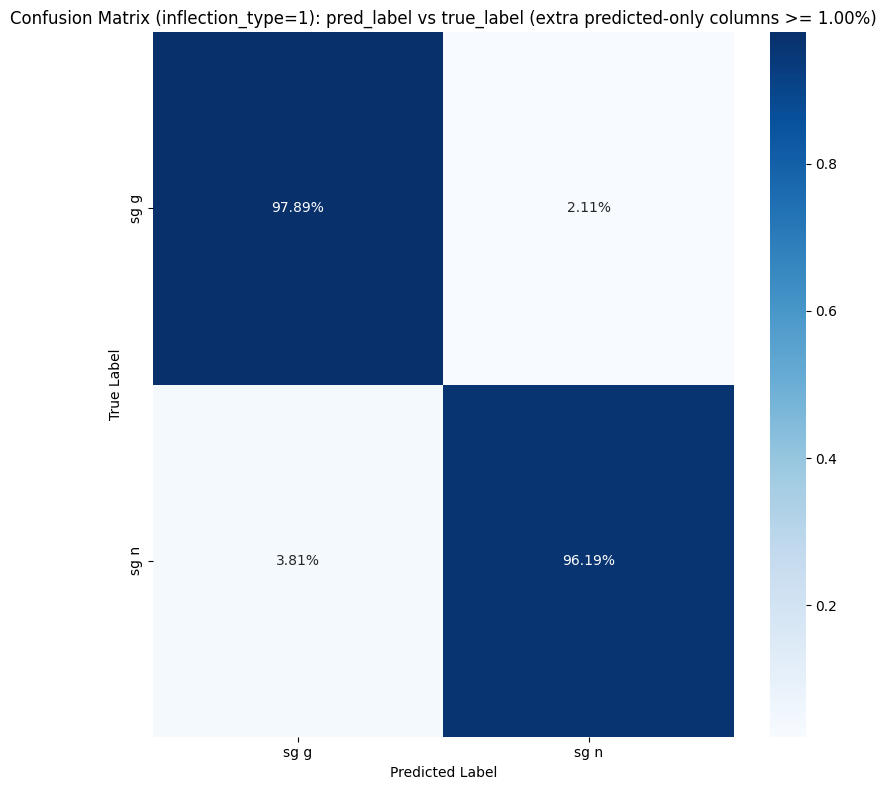

Confusion Matrix (inflection_type=1): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      1       0.05             False            1.0
1                 pl g      1       0.05             False            1.0
2                 sg p      1       0.05             False            1.0
Sum of true labels count: 1996


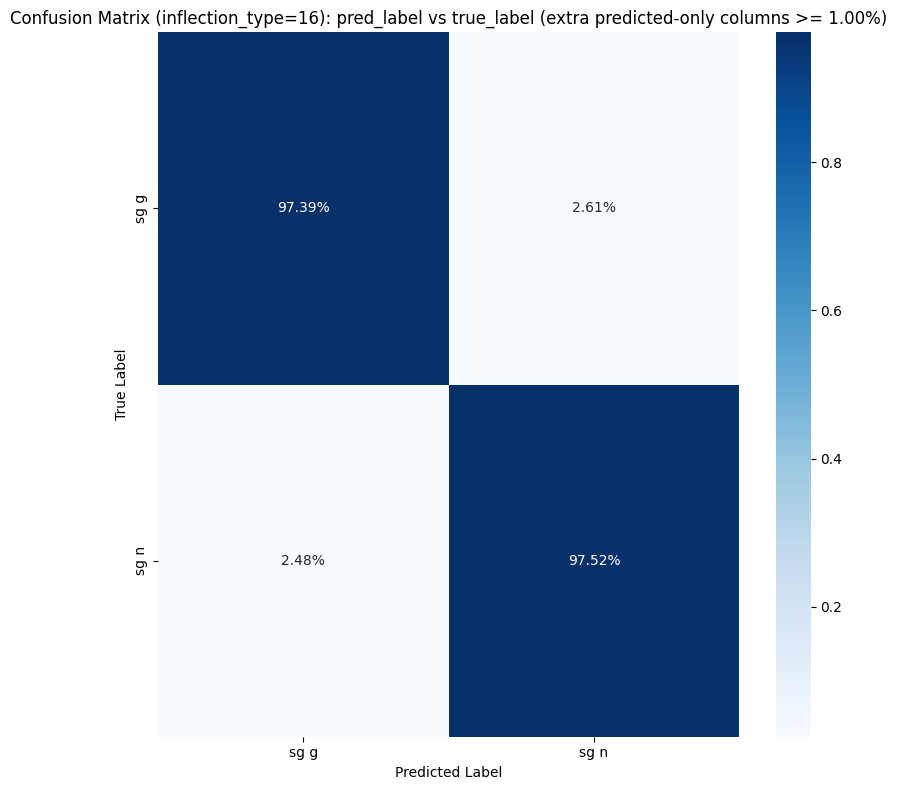

Confusion Matrix (inflection_type=16): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    -      5       0.25             False            1.0
1                 sg p      5       0.25             False            1.0
2                   me      1       0.05             False            1.0
3                    o      1       0.05             False            1.0
Sum of true labels count: 1970


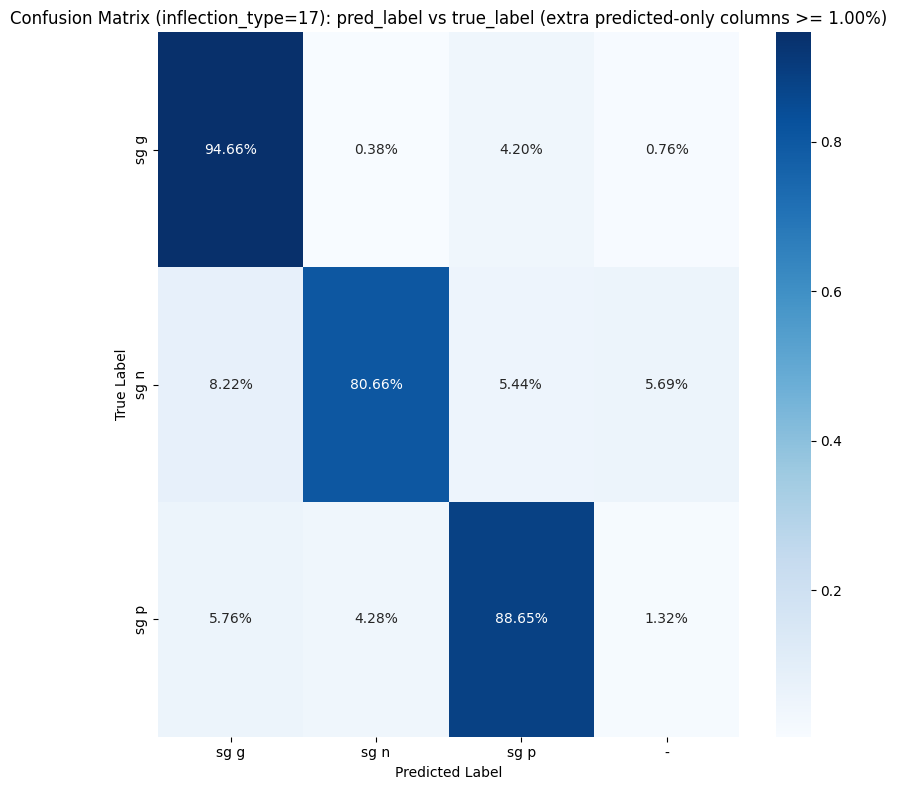

Confusion Matrix (inflection_type=17): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    -     57       2.96              True            1.0
1                 pl p      1       0.05             False            1.0
Sum of true labels count: 1924


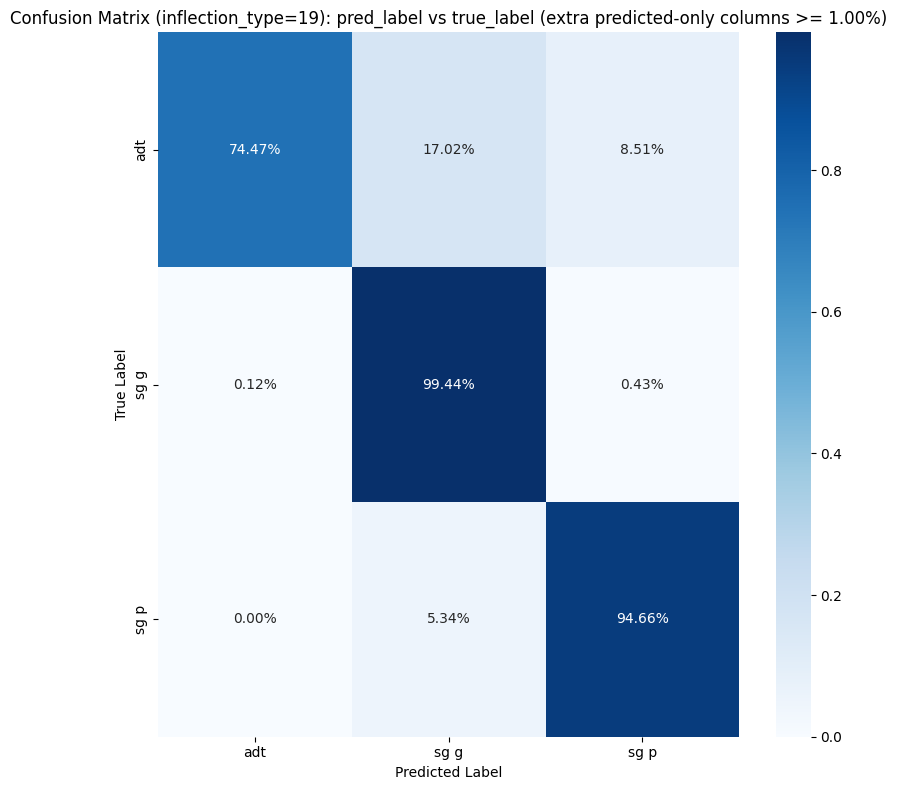

Confusion Matrix (inflection_type=19): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    -      1       0.05             False            1.0
1                 sg n      1       0.05             False            1.0
Sum of true labels count: 1996


In [109]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    save_path=str(
        OUTPUT_DIR
        / "plots"
        / "homonyms"
        / "Bert_morph_v2"
        / "BertMorphTaggerCM_infl.png"
    ),
)

<a id='hindamine_homonyms'></a>


### Evaluation BertMorphTaggerHomonymFull


In [103]:
# Define model to use for annotation
model_name = "../models/NER_mudel_v2_homonym_full/"

In [104]:
results_df = annotate_sentences_with_model(
    input_df=overall_df,
    model_name=model_name,
    output_csv_path=str(
        HOMONYMS_DIRS["processed"]
        / "homonyms_annotations_Bert_morph_V2_homonym_full.csv"
    ),
    progress_desc="Evaluating BertMorphTaggerV2_homonym_full on homonyms dataset",
)

Evaluating BertMorphTaggerV2_homonym_full on homonyms dataset: 100%|██████████| 7886/7886 [07:07<00:00, 18.44it/s]


<a id='tulemused_homonyms'></a>


### Results BertMorphTaggerHomonymFull


In [110]:
# Load results dataframe
results_df = pd.read_csv(
    HOMONYMS_DIRS["processed"] / "homonyms_annotations_Bert_morph_V2_homonym_full.csv",
    index_col=False,
)

print("BertMorphTaggerV2_homonym_full results:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)

BertMorphTaggerV2_homonym_full results:
Overall results
Accuracy:  99.91%
Precision: 99.91%
Recall:    99.91%
F1-score:  99.91%


In [111]:
# Print classification reports
print("BertMorphTaggerV2_homonym_full classification report:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV2_homonym_full classification report:
Overall results - Classification Report
              precision    recall  f1-score   support

         adt       1.00      1.00      1.00        94
        sg g       1.00      1.00      1.00      4457
        sg n       1.00      1.00      1.00      2445
        sg p       1.00      1.00      1.00       890

    accuracy                           1.00      7886
   macro avg       1.00      1.00      1.00      7886
weighted avg       1.00      1.00      1.00      7886



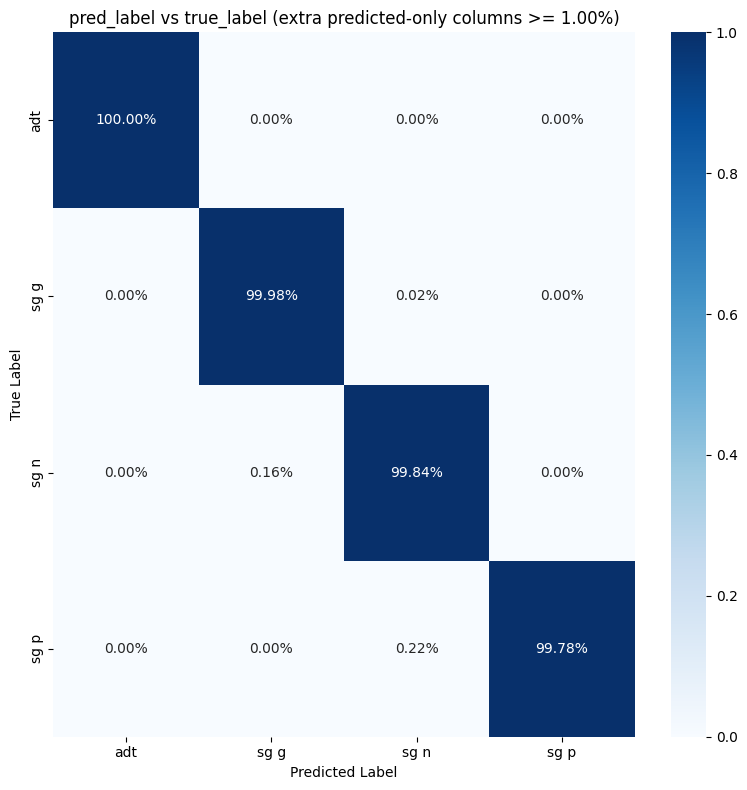

In [112]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    save_path=str(
        OUTPUT_DIR
        / "plots"
        / "homonyms"
        / "Bert_morph_v2_homonym_full"
        / "BertMorphTaggerCM.png"
    ),
)

In [113]:
# Generate results per inflection type
print("BertMorphTaggerV2_homonym_full results per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=True,
    show_classification_report=False,
)

BertMorphTaggerV2_homonym_full results per inflection type:
inflection_type=1
Accuracy:  100.00%
Precision: 100.00%
Recall:    100.00%
F1-score:  100.00%
inflection_type=16
Accuracy:  99.90%
Precision: 99.90%
Recall:    99.90%
F1-score:  99.90%
inflection_type=17
Accuracy:  99.79%
Precision: 99.79%
Recall:    99.79%
F1-score:  99.79%
inflection_type=19
Accuracy:  99.95%
Precision: 100.00%
Recall:    99.95%
F1-score:  99.97%


In [114]:
# Generate classification reports per inflection type
print("BertMorphTaggerV2_homonym_full classification reports per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV2_homonym_full classification reports per inflection type:
inflection_type=1 - Classification Report
              precision    recall  f1-score   support

        sg g       1.00      1.00      1.00      1232
        sg n       1.00      1.00      1.00       764

    accuracy                           1.00      1996
   macro avg       1.00      1.00      1.00      1996
weighted avg       1.00      1.00      1.00      1996

inflection_type=16 - Classification Report
              precision    recall  f1-score   support

        sg g       1.00      1.00      1.00      1080
        sg n       1.00      1.00      1.00       890

    accuracy                           1.00      1970
   macro avg       1.00      1.00      1.00      1970
weighted avg       1.00      1.00      1.00      1970

inflection_type=17 - Classification Report
              precision    recall  f1-score   support

        sg g       1.00      1.00      1.00       524
        sg n       1.00      1.00 

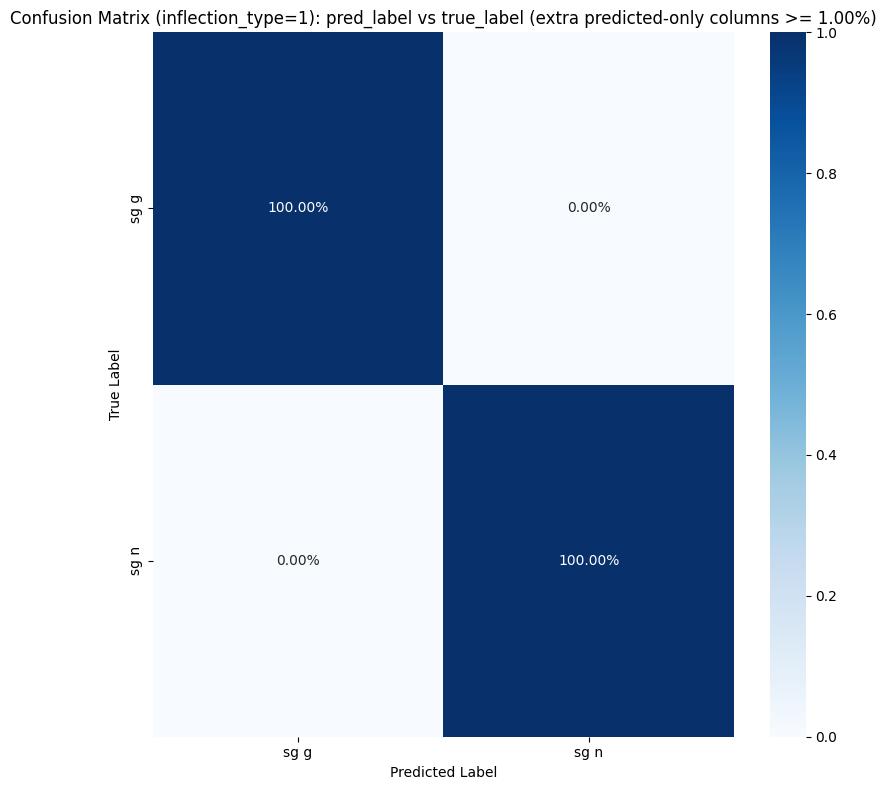

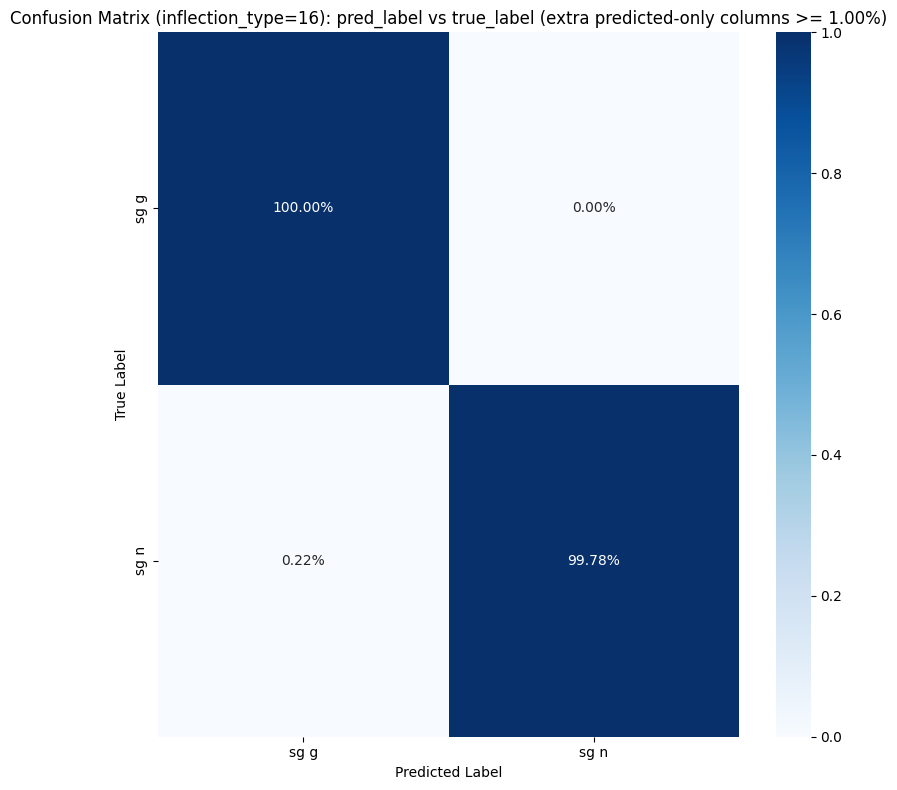

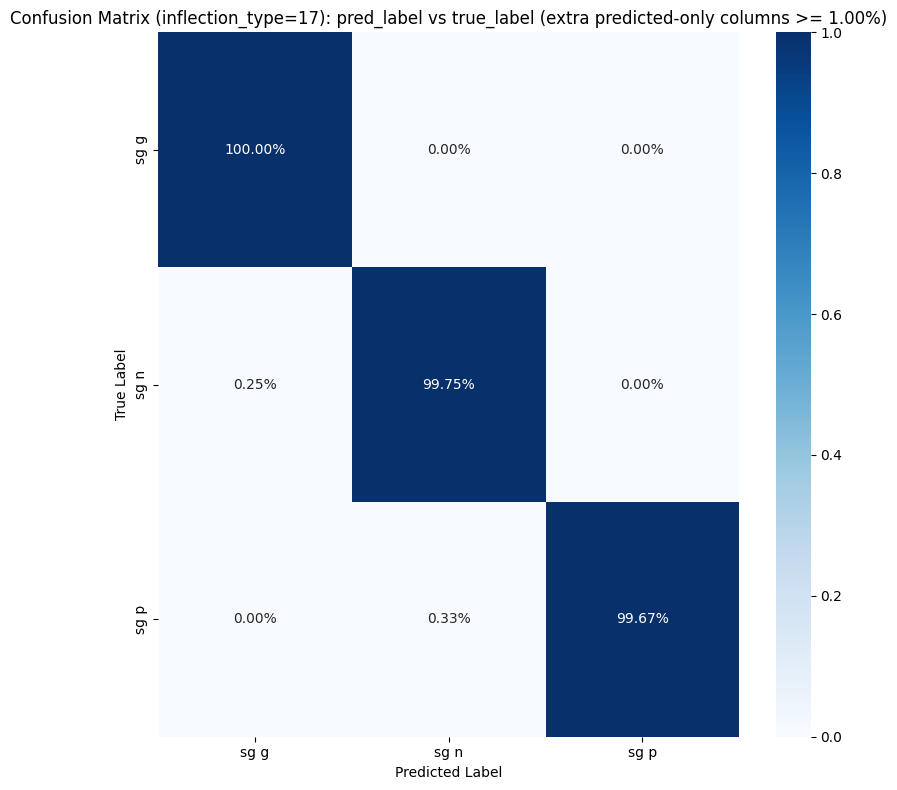

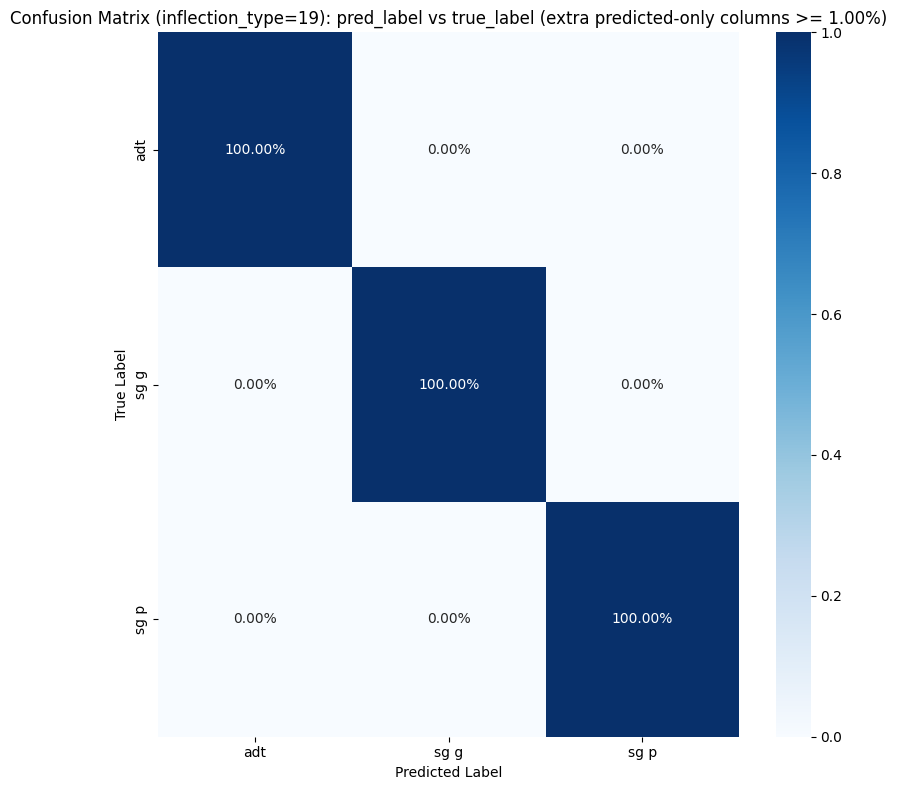

Confusion Matrix (inflection_type=19): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg n      1       0.05             False            1.0
Sum of true labels count: 1996


In [115]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    save_path=str(
        OUTPUT_DIR
        / "plots"
        / "homonyms"
        / "Bert_morph_v2_homonym_full"
        / "BertMorphTaggerCM_infl.png"
    ),
)

<a id='hindamine_homonyms_50'></a>


### Evaluation BertMorphTaggerHomonym_50


In [152]:
# Define model to use for annotation
model_name = "../models/NER_mudel_v2_homonym_50/"

In [153]:
test_df = pd.read_parquet(
    "../data/homonymous_word_forms/processed/homonyms_test.parquet"
)

In [154]:
display(overall_df.head())
display(test_df.head())

,num,inflection_type,sentence,word,word_span,label,sentence_id,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"(74, 80)",[sg n],0,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"(20, 27)",[sg n],1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"(51, 60)",[sg n],2,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"(16, 20)",[sg n],3,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"(0, 7)",[sg g],4,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


,sentence_id,words,form,pos,labels,infl_type,source
0,22,Kakskümmend,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,22,aastat,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,22,tagasi,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,22,töötasin,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,22,teadurina,-,-,-,1,infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


In [159]:
print(len(test_df[test_df["labels"] != "-"]), "sentences")

3943 sentences


In [163]:
# Gather homonym rows present in the test set
test_homonym_rows = test_df[test_df["labels"] != "-"]
# Gather corresponding rows from the overall dataframe
# Group sentence_id and source to ensure we get the correct sentences
test_sentence_groups = (
    test_homonym_rows.groupby(["sentence_id", "source"])
    .size()
    .reset_index()[["sentence_id", "source"]]
)
test_overall_rows = pd.merge(
    test_sentence_groups,
    overall_df,
    on=["sentence_id", "source"],
    how="inner",
)
print(
    f"Found {len(test_overall_rows)} matching rows in overall dataframe for the test set."
)

Found 3943 matching rows in overall dataframe for the test set.


In [165]:
display(test_overall_rows.head())

,sentence_id,source,num,inflection_type,sentence,word,word_span,label
0,1,infl_type_01_1000_v2_project-5-at-2024-12-11-21-53-280753b4.json,2,1,"Mööda uisutab üks Kandle Ott, kelle käisest paistab arvuti.",arvuti,"(52, 58)",[sg n]
1,1,infl_type_16_1000_v2_project-5-at-2025-01-03-01-42-87bca577.json,2,16,"Diana limusiini jälitanud prantsuse kõmufotograafid tormasid kohemaid klõpsima, kui auto oli vastu Alma silla tunneli betoonposti kihutanud.",Alma,"(99, 103)",[sg g]
2,1,infl_type_17_1000_v2.json,2,17,""" Leigo talu annab tööd kokku kümnekonnale inimesele.",talu,"(8, 12)",[sg n]
3,1,infl_type_19_1000_v2_project-7-at-2025-11-21-23-02-24f590e4.json,2,19,Tulumaksu alandamine 20 protsendini ja maksuvaba miinimumi tõstmine loovad tema väitel asja elluviimiseks head eeldused.,miinimumi,"(49, 58)",[sg g]
4,2,infl_type_16_1000_v2_project-5-at-2025-01-03-01-42-87bca577.json,2,16,"Valga põhikooli ettevõtmisele panid õla alla programm Phare Access 2002, Valga linnavalitsus, RMK Valga metskond, Valgamaa alaealiste komisjon ja stuudio Naeratus.",Valga,"(73, 78)",[sg g]


In [167]:
results_df = annotate_sentences_with_model(
    input_df=test_overall_rows,
    model_name=model_name,
    output_csv_path=str(
        HOMONYMS_DIRS["processed"] / "homonyms_evaluation_results_v2_homonym_50.csv"
    ),
    progress_desc="Evaluating BertMorphTaggerHomonym_50",
)

Evaluating BertMorphTaggerHomonym_50: 100%|██████████| 3943/3943 [03:38<00:00, 18.05it/s]


<a id='tulemused_homonyms_50'></a>


### Results BertMorphTaggerHomonyms_50


In [116]:
# Load results dataframe
results_df = pd.read_csv(
    HOMONYMS_DIRS["processed"] / "homonyms_evaluation_results_v2_homonym_50.csv",
    index_col=False,
)

print("BertMorphTaggerV2_homonym_50 results:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)

BertMorphTaggerV2_homonym_50 results:
Overall results
Accuracy:  96.15%
Precision: 96.23%
Recall:    96.15%
F1-score:  96.15%


In [117]:
# Print classification reports
print("BertMorphTaggerV2_homonym_50 classification report:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV2_homonym_50 classification report:
Overall results - Classification Report
              precision    recall  f1-score   support

         adt       0.93      0.90      0.92        31
           o       0.00      0.00      0.00         0
        sg g       0.97      0.99      0.98      2335
        sg n       0.98      0.92      0.95      1107
        sg p       0.89      0.93      0.91       470

    accuracy                           0.96      3943
   macro avg       0.75      0.75      0.75      3943
weighted avg       0.96      0.96      0.96      3943



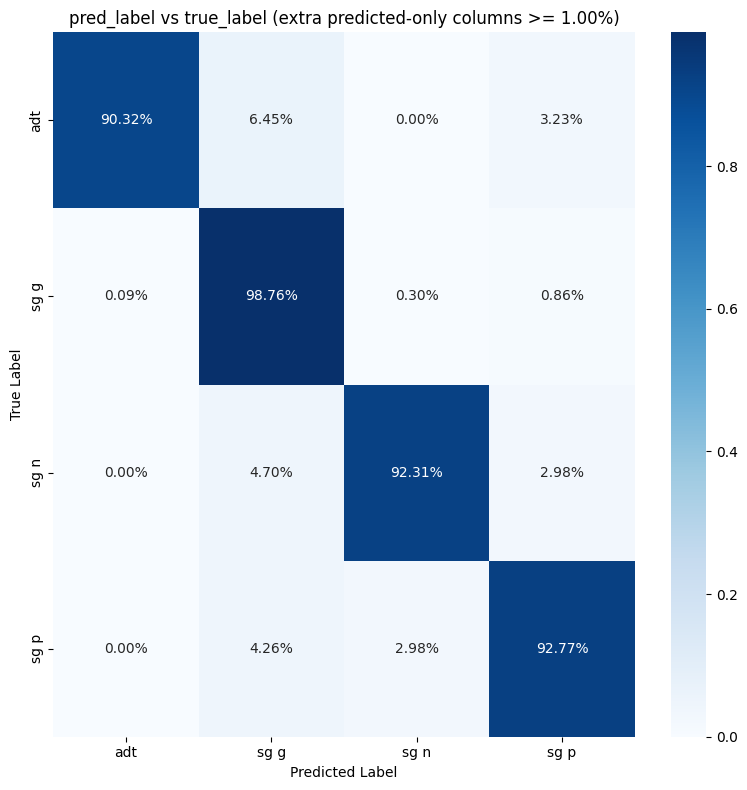

pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    o      1       0.03             False            1.0
Sum of true labels count: 3943


In [118]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    save_path=str(
        OUTPUT_DIR
        / "plots"
        / "homonyms"
        / "Bert_morph_v2_homonym_50"
        / "BertMorphTaggerCM.png"
    ),
)

In [119]:
# Generate results per inflection type
print("BertMorphTaggerV2_homonym_50 results per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=True,
    show_classification_report=False,
)

BertMorphTaggerV2_homonym_50 results per inflection type:
inflection_type=1
Accuracy:  97.91%
Precision: 98.03%
Recall:    97.91%
F1-score:  97.95%
inflection_type=16
Accuracy:  98.81%
Precision: 99.04%
Recall:    98.81%
F1-score:  98.92%
inflection_type=17
Accuracy:  90.13%
Precision: 90.61%
Recall:    90.13%
F1-score:  90.16%
inflection_type=19
Accuracy:  98.22%
Precision: 98.27%
Recall:    98.22%
F1-score:  98.23%


In [120]:
# Generate classification reports per inflection type
print("BertMorphTaggerV2_homonym_50 classification reports per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV2_homonym_50 classification reports per inflection type:
inflection_type=1 - Classification Report
              precision    recall  f1-score   support

         adt       0.00      0.00      0.00         0
        sg g       0.98      0.99      0.98       605
        sg n       0.99      0.95      0.97       303

    accuracy                           0.98       908
   macro avg       0.65      0.65      0.65       908
weighted avg       0.98      0.98      0.98       908

inflection_type=16 - Classification Report
              precision    recall  f1-score   support

           o       0.00      0.00      0.00         0
        sg g       0.99      1.00      0.99       568
        sg n       1.00      0.97      0.98       358
        sg p       0.00      0.00      0.00         0

    accuracy                           0.99       926
   macro avg       0.50      0.49      0.49       926
weighted avg       0.99      0.99      0.99       926

inflection_type=17 - Class

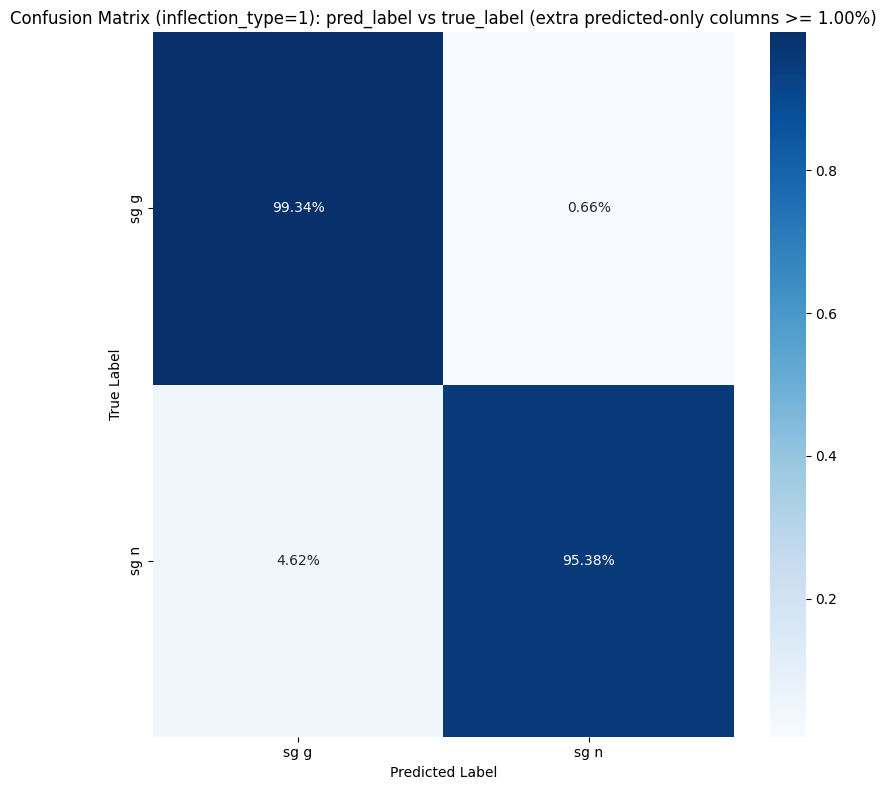

Confusion Matrix (inflection_type=1): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      1       0.11             False            1.0
Sum of true labels count: 908


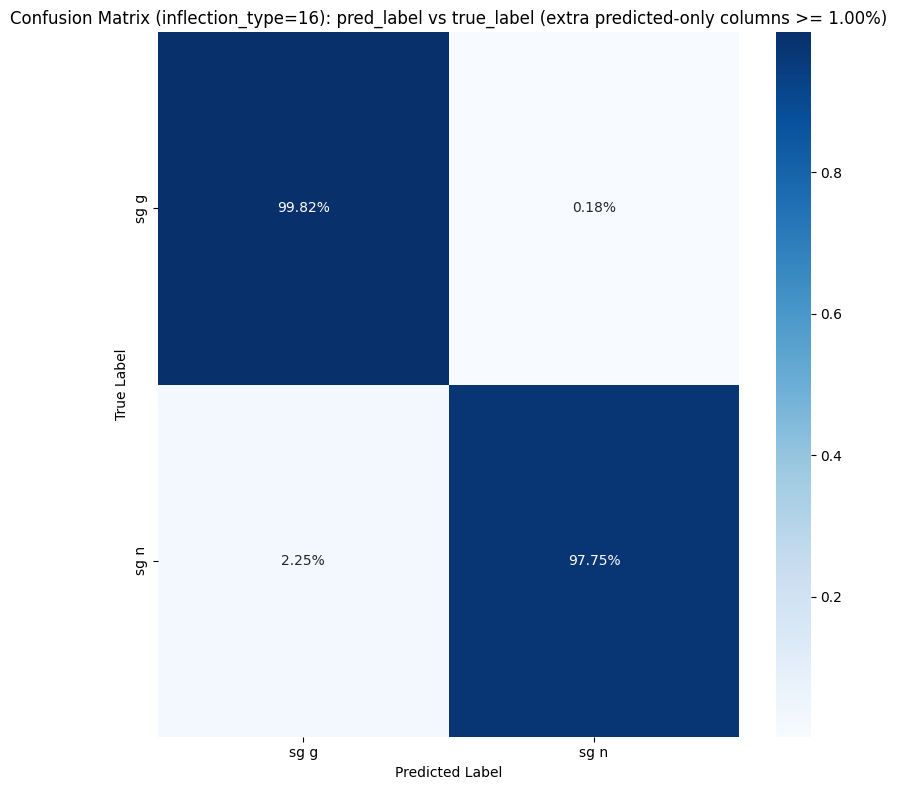

Confusion Matrix (inflection_type=16): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    o      1       0.11             False            1.0
1                 sg p      1       0.11             False            1.0
Sum of true labels count: 926


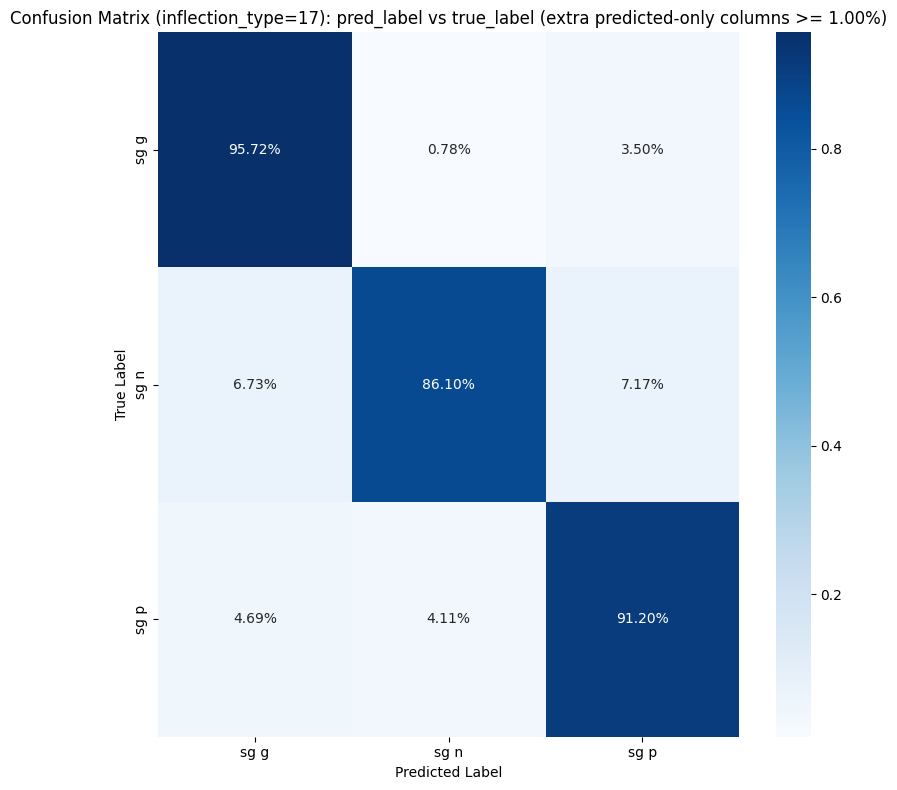

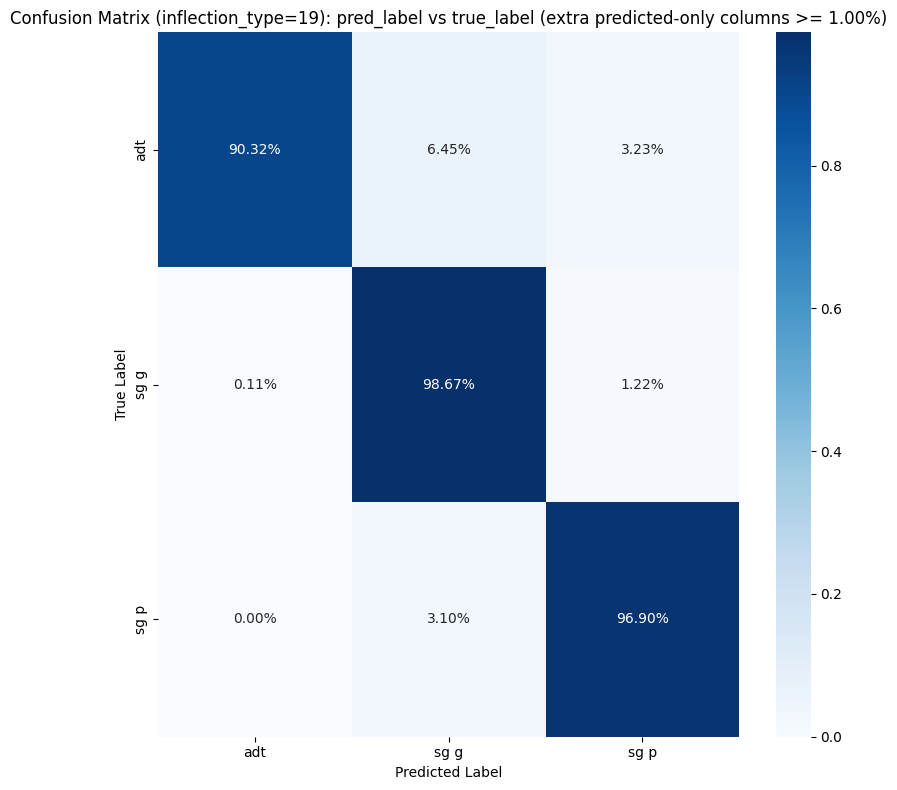

In [121]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    save_path=str(
        OUTPUT_DIR
        / "plots"
        / "homonyms"
        / "Bert_morph_v2_homonym_50"
        / "BertMorphTaggerCM_infl.png"
    ),
)

### Baseline models (random choice and most frequent choice)


### Label distribution


In [15]:
# View label distribution in the dataset

# Count occurrences of each label in the entire dataset
label_distribution_overall = (
    results_df.groupby("true_label").size().reset_index(name="count")
)

# Calculate percentages
label_distribution_overall["percentage"] = label_distribution_overall["count"].apply(
    lambda x: round(x / label_distribution_overall["count"].sum() * 100, 3)
)
print("=" * 5, "Overall Label Distribution", "=" * 5)
print(label_distribution_overall, "\n")


# View label distribution per inflection type and add percentage columns
print("=" * 5, "Label Distribution per Inflection Type", "=" * 5)

# Count occurrences of each label per inflection type
label_distribution = (
    results_df.groupby(["inflection_type", "true_label"])
    .size()
    .reset_index(name="count")
)

# Calculate percentages
label_distribution["percentage"] = label_distribution.groupby("inflection_type")[
    "count"
].transform(lambda x: round(x / x.sum() * 100, 3))

# Separate dataframes per inflection type
label_distribution_dfs = {}
for infl_type in label_distribution["inflection_type"].unique():
    label_distribution_dfs[infl_type] = label_distribution[
        label_distribution["inflection_type"] == infl_type
    ].reset_index(drop=True)
    print(f"Inflection Type {infl_type} Label Distribution:")
    print(label_distribution_dfs[infl_type])

===== Overall Label Distribution =====
  true_label  count  percentage
0        adt     94       1.192
1       sg g   4457      56.518
2       sg n   2445      31.004
3       sg p    890      11.286 

===== Label Distribution per Inflection Type =====
Inflection Type 1 Label Distribution:
   inflection_type true_label  count  percentage
0                1       sg g   1232      61.723
1                1       sg n    764      38.277
Inflection Type 16 Label Distribution:
   inflection_type true_label  count  percentage
0               16       sg g   1080      54.822
1               16       sg n    890      45.178
Inflection Type 17 Label Distribution:
   inflection_type true_label  count  percentage
0               17       sg g    524      27.235
1               17       sg n    791      41.112
2               17       sg p    609      31.653
Inflection Type 19 Label Distribution:
   inflection_type true_label  count  percentage
0               19        adt     94       4.709
1    

#### Overall homonym dataset


In [15]:
seed = 42069360
# Create a most frequent class baseline
most_frequent_baseline = sklearn.dummy.DummyClassifier(
    strategy="most_frequent", random_state=seed
)
# Create a random choice baseline
random_choice_baseline = sklearn.dummy.DummyClassifier(
    strategy="uniform", random_state=seed
)

In [16]:
# Fit and evaluate baselines
for baseline, name in [
    (most_frequent_baseline, "Most Frequent Class Baseline"),
    (random_choice_baseline, "Random Choice Baseline"),
]:
    baseline.fit(
        results_df["true_label"],
        results_df["true_label"],
    )
    baseline_predictions = baseline.predict(
        results_df["true_label"],
    )
    baseline_cr = sklearn.metrics.classification_report(
        y_true=results_df["true_label"],
        y_pred=baseline_predictions,
        zero_division=0,
    )
    print(f"{name} Classification Report:")
    print(baseline_cr)

Most Frequent Class Baseline Classification Report:
              precision    recall  f1-score   support

         adt       0.00      0.00      0.00        94
        sg g       0.57      1.00      0.72      4457
        sg n       0.00      0.00      0.00      2445
        sg p       0.00      0.00      0.00       890

    accuracy                           0.57      7886
   macro avg       0.14      0.25      0.18      7886
weighted avg       0.32      0.57      0.41      7886

Random Choice Baseline Classification Report:
              precision    recall  f1-score   support

         adt       0.01      0.27      0.02        94
        sg g       0.55      0.25      0.34      4457
        sg n       0.31      0.25      0.28      2445
        sg p       0.11      0.25      0.16       890

    accuracy                           0.25      7886
   macro avg       0.25      0.25      0.20      7886
weighted avg       0.42      0.25      0.30      7886



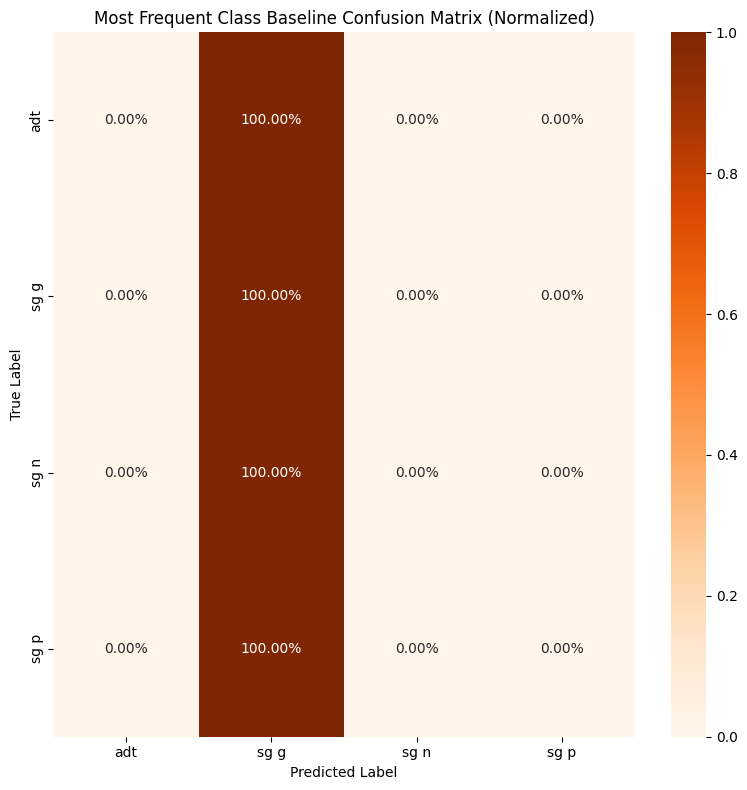

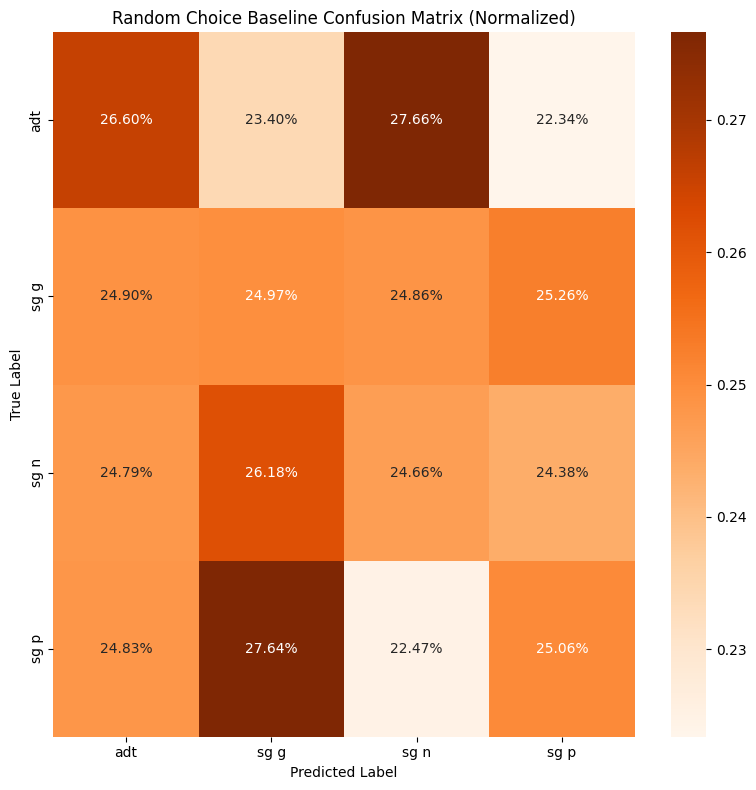

In [ ]:
# Plot confusion matrices for overall results with baselines
for baseline, name in [
    (most_frequent_baseline, "Most Frequent Class Baseline"),
    (random_choice_baseline, "Random Choice Baseline"),
]:
    baseline_predictions = baseline.predict(
        results_df["true_label"],
    )
    baseline_cm = sklearn.metrics.confusion_matrix(
        y_true=results_df["true_label"], y_pred=baseline_predictions
    )
    baseline_cm_normalized = (
        baseline_cm.astype("float") / baseline_cm.sum(axis=1)[:, np.newaxis]
    )
    plt.figure(figsize=(8, 8))
    sns.heatmap(
        baseline_cm_normalized,
        annot=True,
        fmt=".2%",
        cmap="Oranges",
        xticklabels=np.unique(results_df["true_label"]),
        yticklabels=np.unique(results_df["true_label"]),
    )
    plt.title(f"{name} Confusion Matrix (Normalized)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(
        "../outputs/plots/baseline/homonym/" + name.replace(" ", "") + "CM", dpi=300
    )
    plt.show()

#### Per inflection type homonym dataset


In [20]:
seed = 42069360
# Create a most frequent class baseline
most_frequent_baseline = sklearn.dummy.DummyClassifier(
    strategy="most_frequent", random_state=seed
)
# Create a random choice baseline
random_choice_baseline = sklearn.dummy.DummyClassifier(
    strategy="uniform", random_state=seed
)

In [21]:
# Fit and evaluate baselines
for baseline, name in [
    (most_frequent_baseline, "Most Frequent Class Baseline"),
    (random_choice_baseline, "Random Choice Baseline"),
]:
    for inflection_type in results_df["inflection_type"].unique():
        baseline.fit(
            results_df[results_df["inflection_type"] == inflection_type]["true_label"],
            results_df[results_df["inflection_type"] == inflection_type]["true_label"],
        )
        baseline_predictions = baseline.predict(
            results_df[results_df["inflection_type"] == inflection_type]["true_label"],
        )
        baseline_cr = sklearn.metrics.classification_report(
            y_true=results_df[results_df["inflection_type"] == inflection_type][
                "true_label"
            ],
            y_pred=baseline_predictions,
            zero_division=0,
        )
        print(f"{name} Classification Report for Inflection Type {inflection_type}:")
        print(baseline_cr)

Most Frequent Class Baseline Classification Report for Inflection Type 1:
              precision    recall  f1-score   support

        sg g       0.62      1.00      0.76      1232
        sg n       0.00      0.00      0.00       764

    accuracy                           0.62      1996
   macro avg       0.31      0.50      0.38      1996
weighted avg       0.38      0.62      0.47      1996

Most Frequent Class Baseline Classification Report for Inflection Type 16:
              precision    recall  f1-score   support

        sg g       0.55      1.00      0.71      1080
        sg n       0.00      0.00      0.00       890

    accuracy                           0.55      1970
   macro avg       0.27      0.50      0.35      1970
weighted avg       0.30      0.55      0.39      1970

Most Frequent Class Baseline Classification Report for Inflection Type 17:
              precision    recall  f1-score   support

        sg g       0.00      0.00      0.00       524
        sg n 

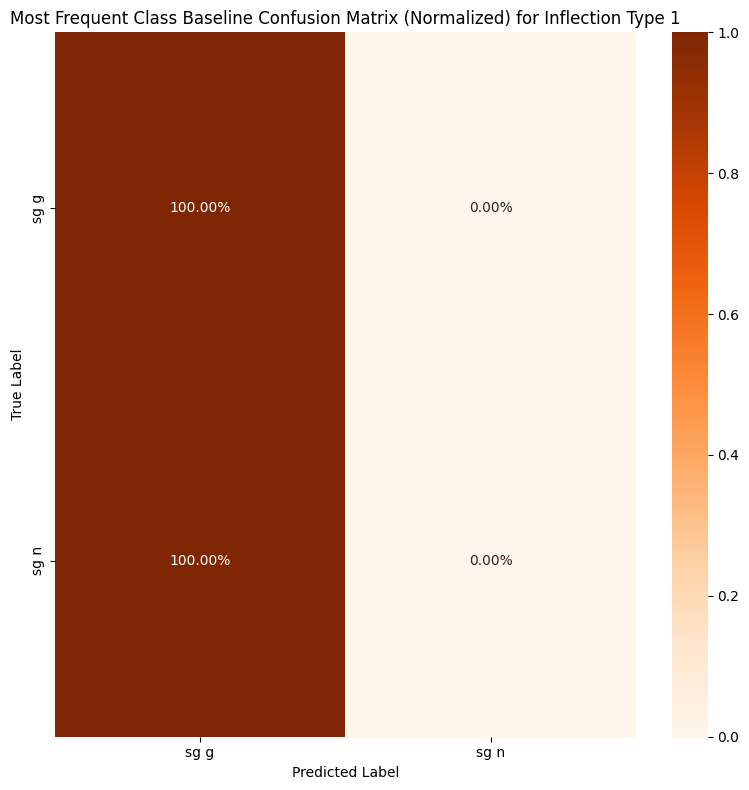

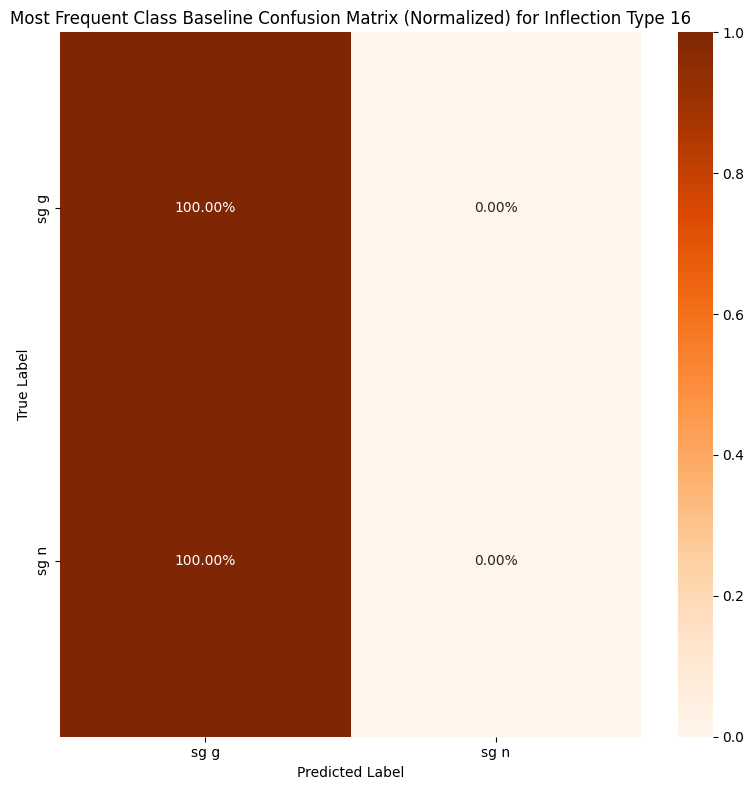

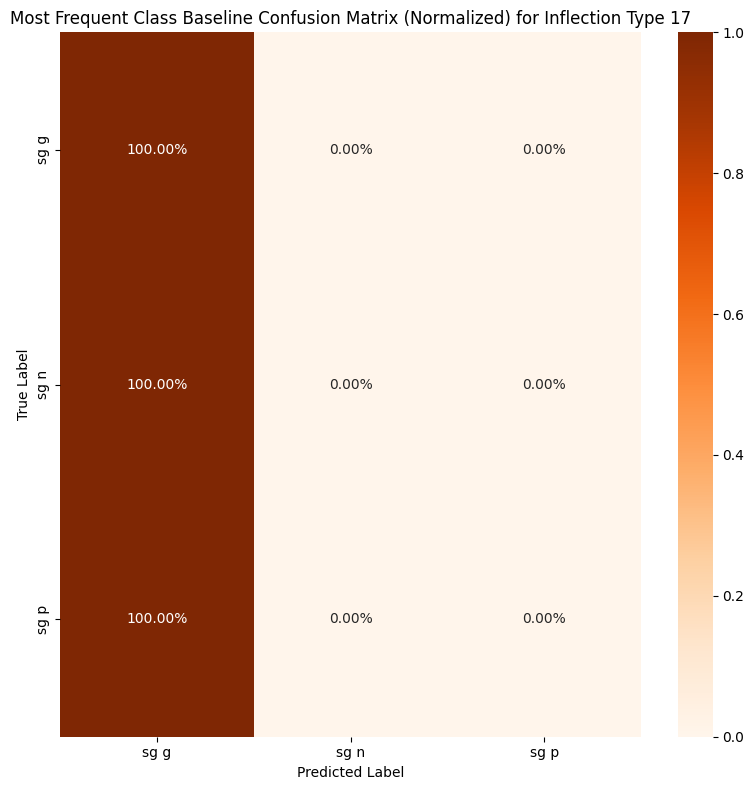

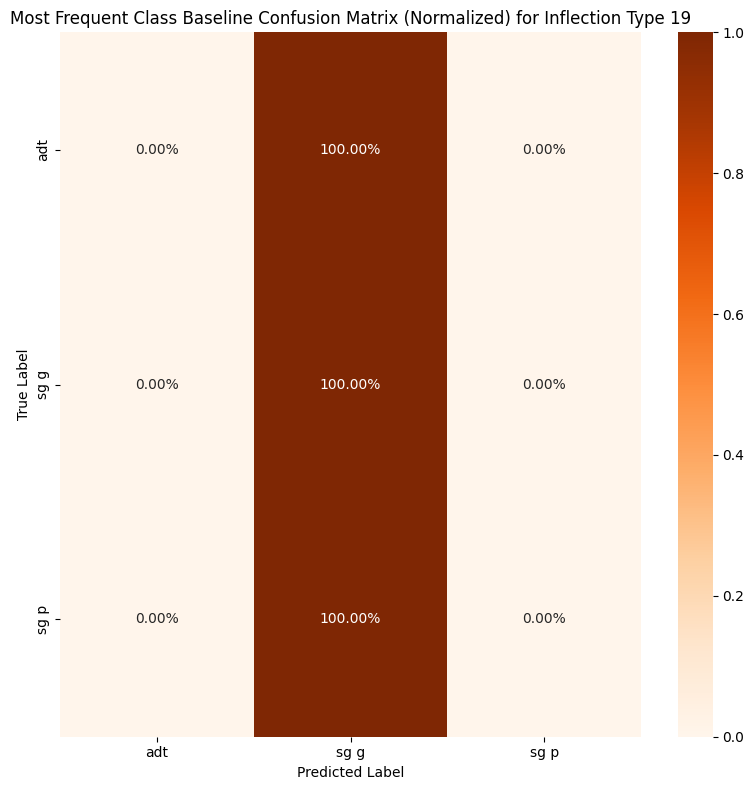

C:\Users\Admin\AppData\Local\Temp\ipykernel_31356\1038238969.py:17: RuntimeWarning: invalid value encountered in divide
  baseline_cm.astype("float") / baseline_cm.sum(axis=1)[:, np.newaxis]


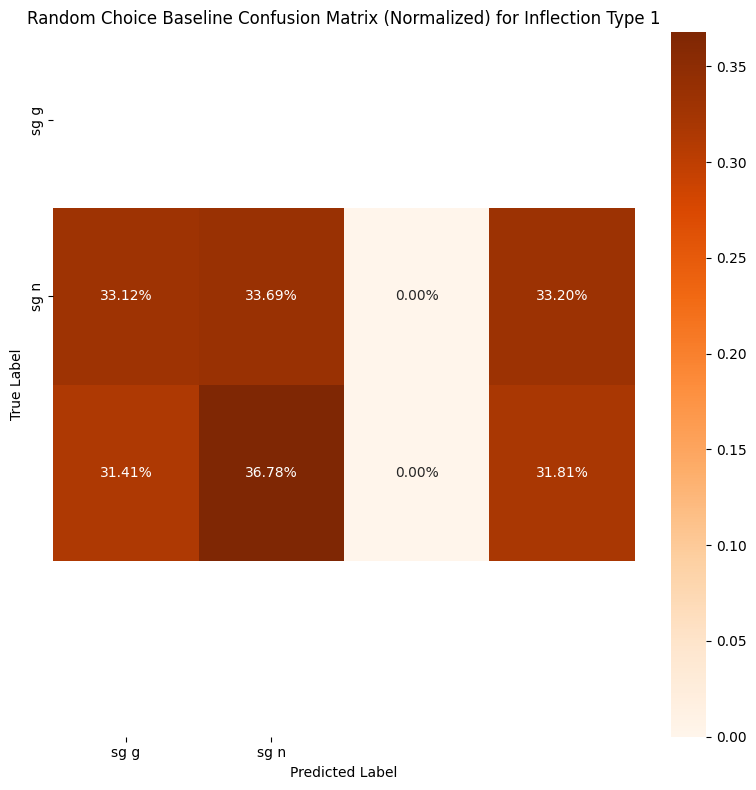

C:\Users\Admin\AppData\Local\Temp\ipykernel_31356\1038238969.py:17: RuntimeWarning: invalid value encountered in divide
  baseline_cm.astype("float") / baseline_cm.sum(axis=1)[:, np.newaxis]


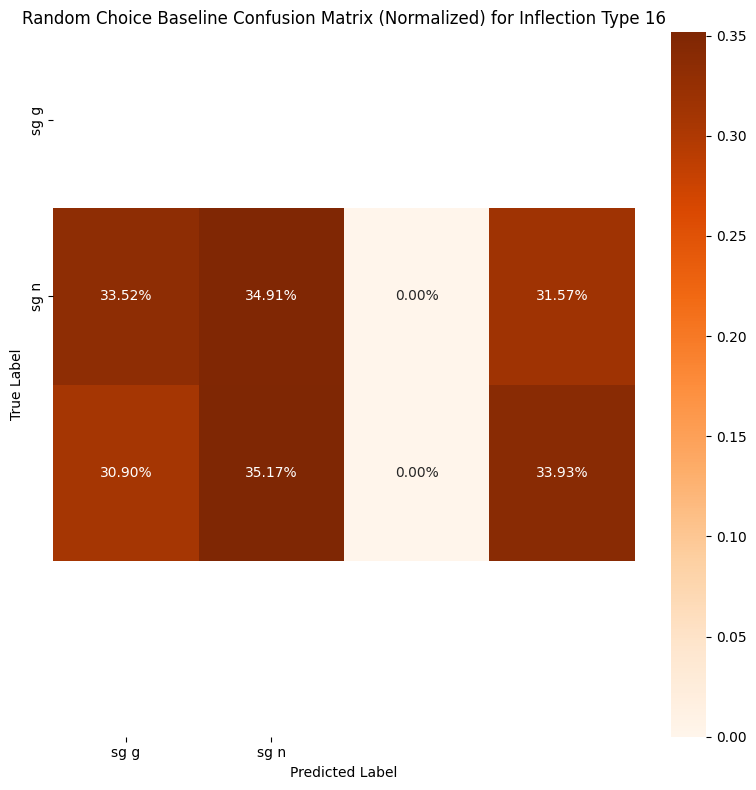

C:\Users\Admin\AppData\Local\Temp\ipykernel_31356\1038238969.py:17: RuntimeWarning: invalid value encountered in divide
  baseline_cm.astype("float") / baseline_cm.sum(axis=1)[:, np.newaxis]


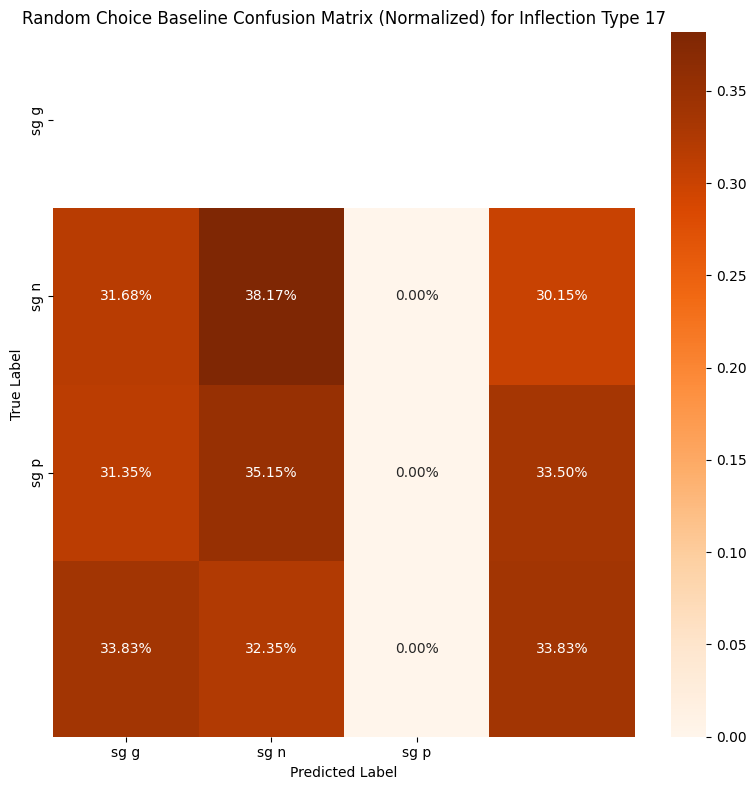

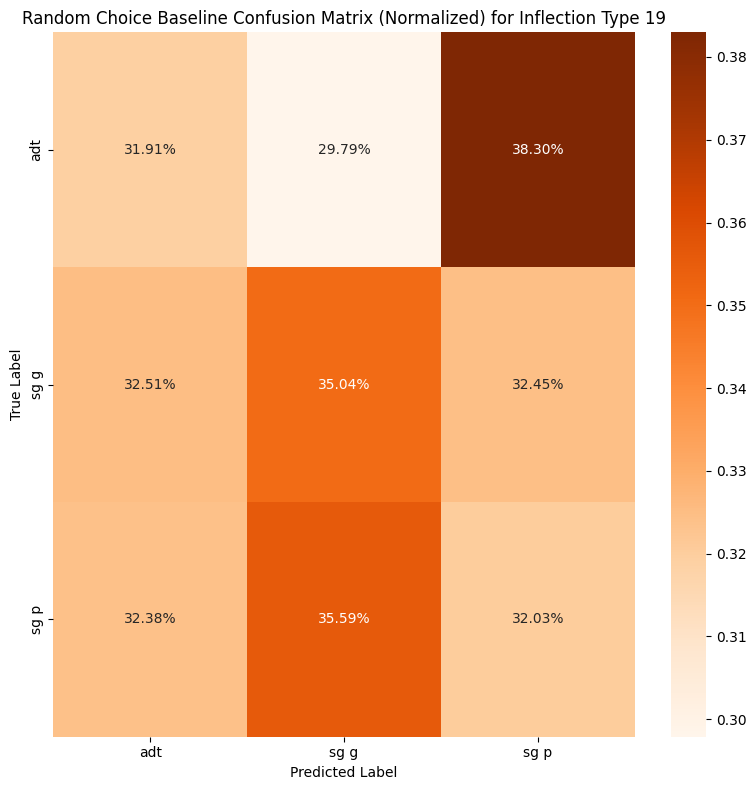

In [ ]:
# Plot confusion matrices per inflection type for baselines
for baseline, name in [
    (most_frequent_baseline, "Most Frequent Class Baseline"),
    (random_choice_baseline, "Random Choice Baseline"),
]:
    for inflection_type in results_df["inflection_type"].unique():
        baseline_predictions = baseline.predict(
            results_df[results_df["inflection_type"] == inflection_type]["true_label"],
        )
        baseline_cm = sklearn.metrics.confusion_matrix(
            y_true=results_df[results_df["inflection_type"] == inflection_type][
                "true_label"
            ],
            y_pred=baseline_predictions,
        )
        baseline_cm_normalized = (
            baseline_cm.astype("float") / baseline_cm.sum(axis=1)[:, np.newaxis]
        )
        plt.figure(figsize=(8, 8))
        sns.heatmap(
            baseline_cm_normalized,
            annot=True,
            fmt=".2%",
            cmap="Oranges",
            xticklabels=np.unique(
                results_df[results_df["inflection_type"] == inflection_type][
                    "true_label"
                ]
            ),
            yticklabels=np.unique(
                results_df[results_df["inflection_type"] == inflection_type][
                    "true_label"
                ]
            ),
        )
        plt.title(
            f"{name} Confusion Matrix (Normalized) for Inflection Type {inflection_type}"
        )
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.tight_layout()
        plt.savefig(
            "../outputs/plots/baseline/homonym/"
            + name.replace(" ", "")
            + "CM_"
            + "infl_"
            + str(inflection_type),
            dpi=300,
        )
        plt.show()

## END
